<a href="https://colab.research.google.com/github/ro-dasilva/datos-colab/blob/main/Copia_de_TP1_Final_Combinado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP1 - Analisis y Visualizacion de Datos: Clasificacion de Reclamos de Telecomunicaciones
## Trabajo Practico Final (fusion de los 3 notebooks: telco, Mentorla_Rocio y Soluciones)

**Estructura y conclusiones:** TP1_Soluciones | **Analisis extra:** Mentorla_Rocio (potencias GPON/OLT, correlacion de Spearman) y telco (asimetria, plazas que concentran el 80% de los reclamos).

> **Como cargar los datos:** ejecuta las celdas en orden. Ajusta `ruta` a la ubicacion del archivo `Dataset_reclamos.csv`. Si trabajas en Google Colab, usa la opcion de cargar el archivo (uploads) antes de la celda de lectura.


## Inicializacion del entorno

In [3]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

import plotly.graph_objs as go
from plotly.offline import init_notebook_mode, iplot
init_notebook_mode(connected=True)

import matplotlib.pyplot as plt
import seaborn as sns
from math import pi

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 50)

In [4]:
ruta = r"Dataset_reclamos.csv"

df = pd.read_csv(
    ruta,
    sep=";",
    quotechar='"',
    engine="python",
    encoding="latin-1",
    on_bad_lines="skip",
    dtype=str
)

print(f"Dimensiones del dataset: {df.shape}")
print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")

Dimensiones del dataset: (176248, 30)
Filas: 176,248 | Columnas: 30


In [5]:
# Conversion de columnas numericas
columnas_numericas = [
    'TPF_POTENCIA_TX_GPON', 'TPF_POTENCIA_RX_GPON',
    'TPF_OLT_POTENCIA_TX', 'TPF_OLT_POTENCIA_RX',
    'DURACION_CORTE_EN_HORAS', 'ANTIGUEDAD_CLIENTE_ANIOS',
    'TPF_CANT_REPE_WIFI'
]

for col in columnas_numericas:
    if col in df.columns:
        df[col] = (
            df[col]
            .astype(str).str.strip()
            .str.replace(',', '.', regex=False)
            .replace({'': np.nan, 'None': np.nan, 'NaN': np.nan,
                      'nan': np.nan, 'Momentaneamente, no se reporta este valor': np.nan})
        )
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Conversion de fechas
for col in ['TPF_FECHA', 'TPF_FECHA_ACTIVA', 'TPF_CORTE_ONT_LASTDW', 'TPF_CORTE_ONT_UPTIME']:
    if col in df.columns:
        df[col + '_DT'] = pd.to_datetime(df[col], format='%d/%m/%Y %H:%M:%S', errors='coerce')

print("Conversiones completadas.")
print(f"\nTipos de datos:")
print(df.dtypes.value_counts())

Conversiones completadas.

Tipos de datos:
object            23
float64            7
datetime64[ns]     4
Name: count, dtype: int64


---
## PREGUNTA 1: Que se observa en la distribucion de las variables?

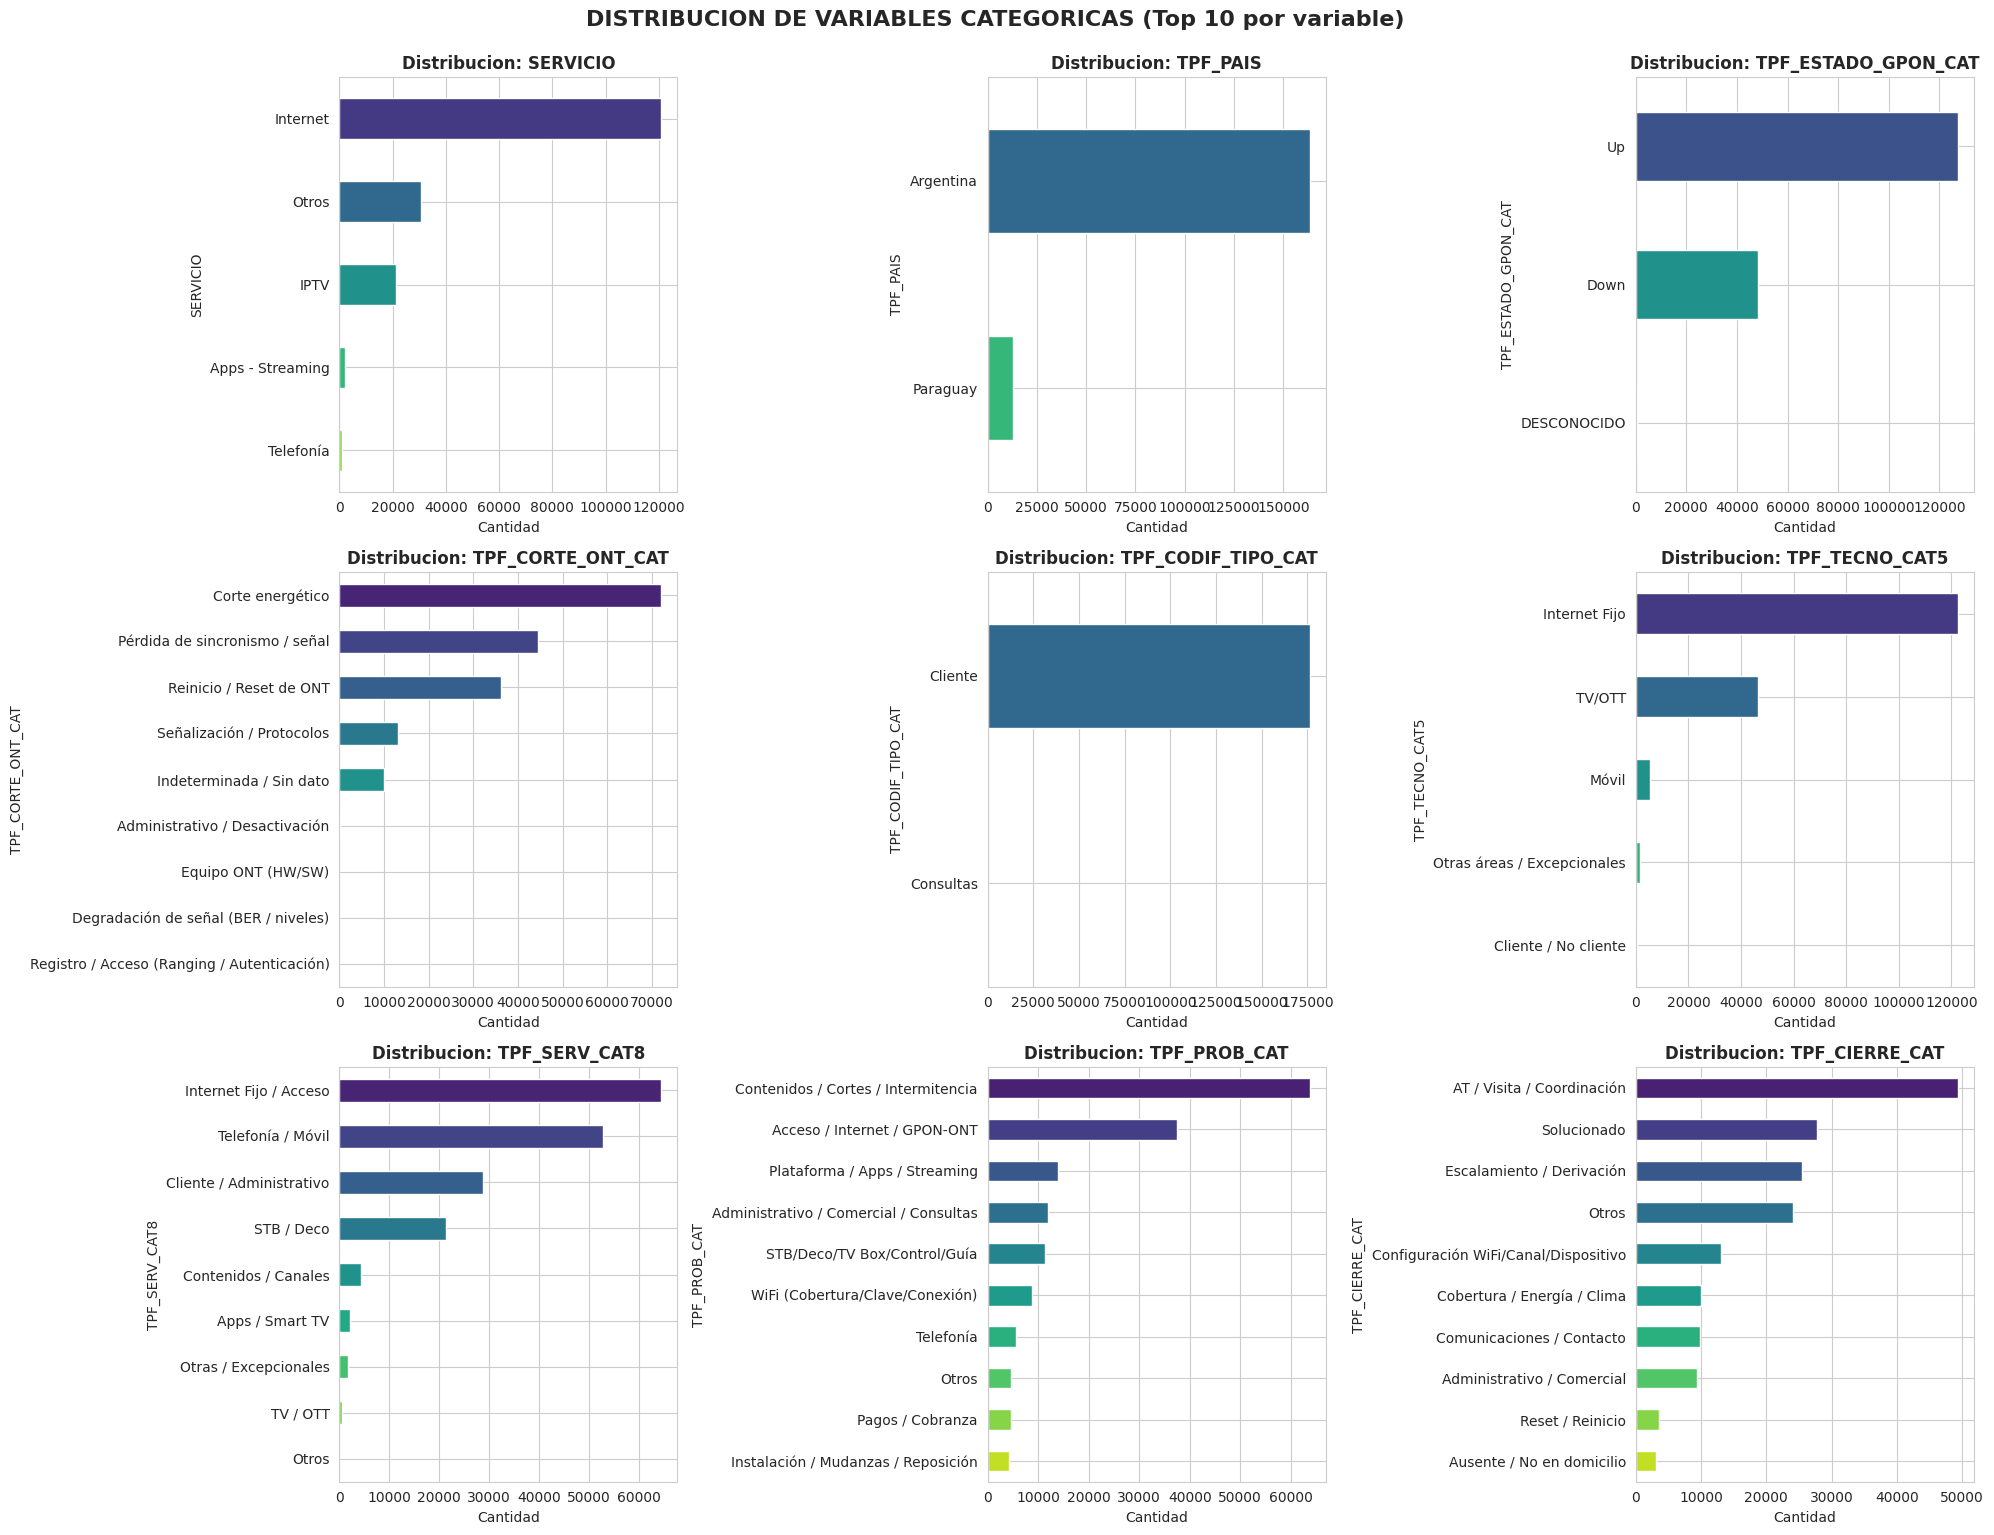

In [6]:
# 1.1 Distribucion de variables categoricas principales
cat_cols = ['SERVICIO', 'TPF_PAIS', 'TPF_ESTADO_GPON_CAT', 'TPF_CORTE_ONT_CAT',
            'TPF_CODIF_TIPO_CAT', 'TPF_TECNO_CAT5', 'TPF_SERV_CAT8', 'TPF_PROB_CAT', 'TPF_CIERRE_CAT']

fig, axes = plt.subplots(3, 3, figsize=(20, 15))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    if col in df.columns:
        top = df[col].value_counts().head(10)
        top.plot(kind='barh', ax=axes[i], color=sns.color_palette('viridis', len(top)))
        axes[i].set_title(f'Distribucion: {col}', fontsize=12, fontweight='bold')
        axes[i].set_xlabel('Cantidad')
        axes[i].invert_yaxis()

plt.tight_layout()
plt.suptitle('DISTRIBUCION DE VARIABLES CATEGORICAS (Top 10 por variable)', y=1.02, fontsize=16, fontweight='bold')
plt.show()

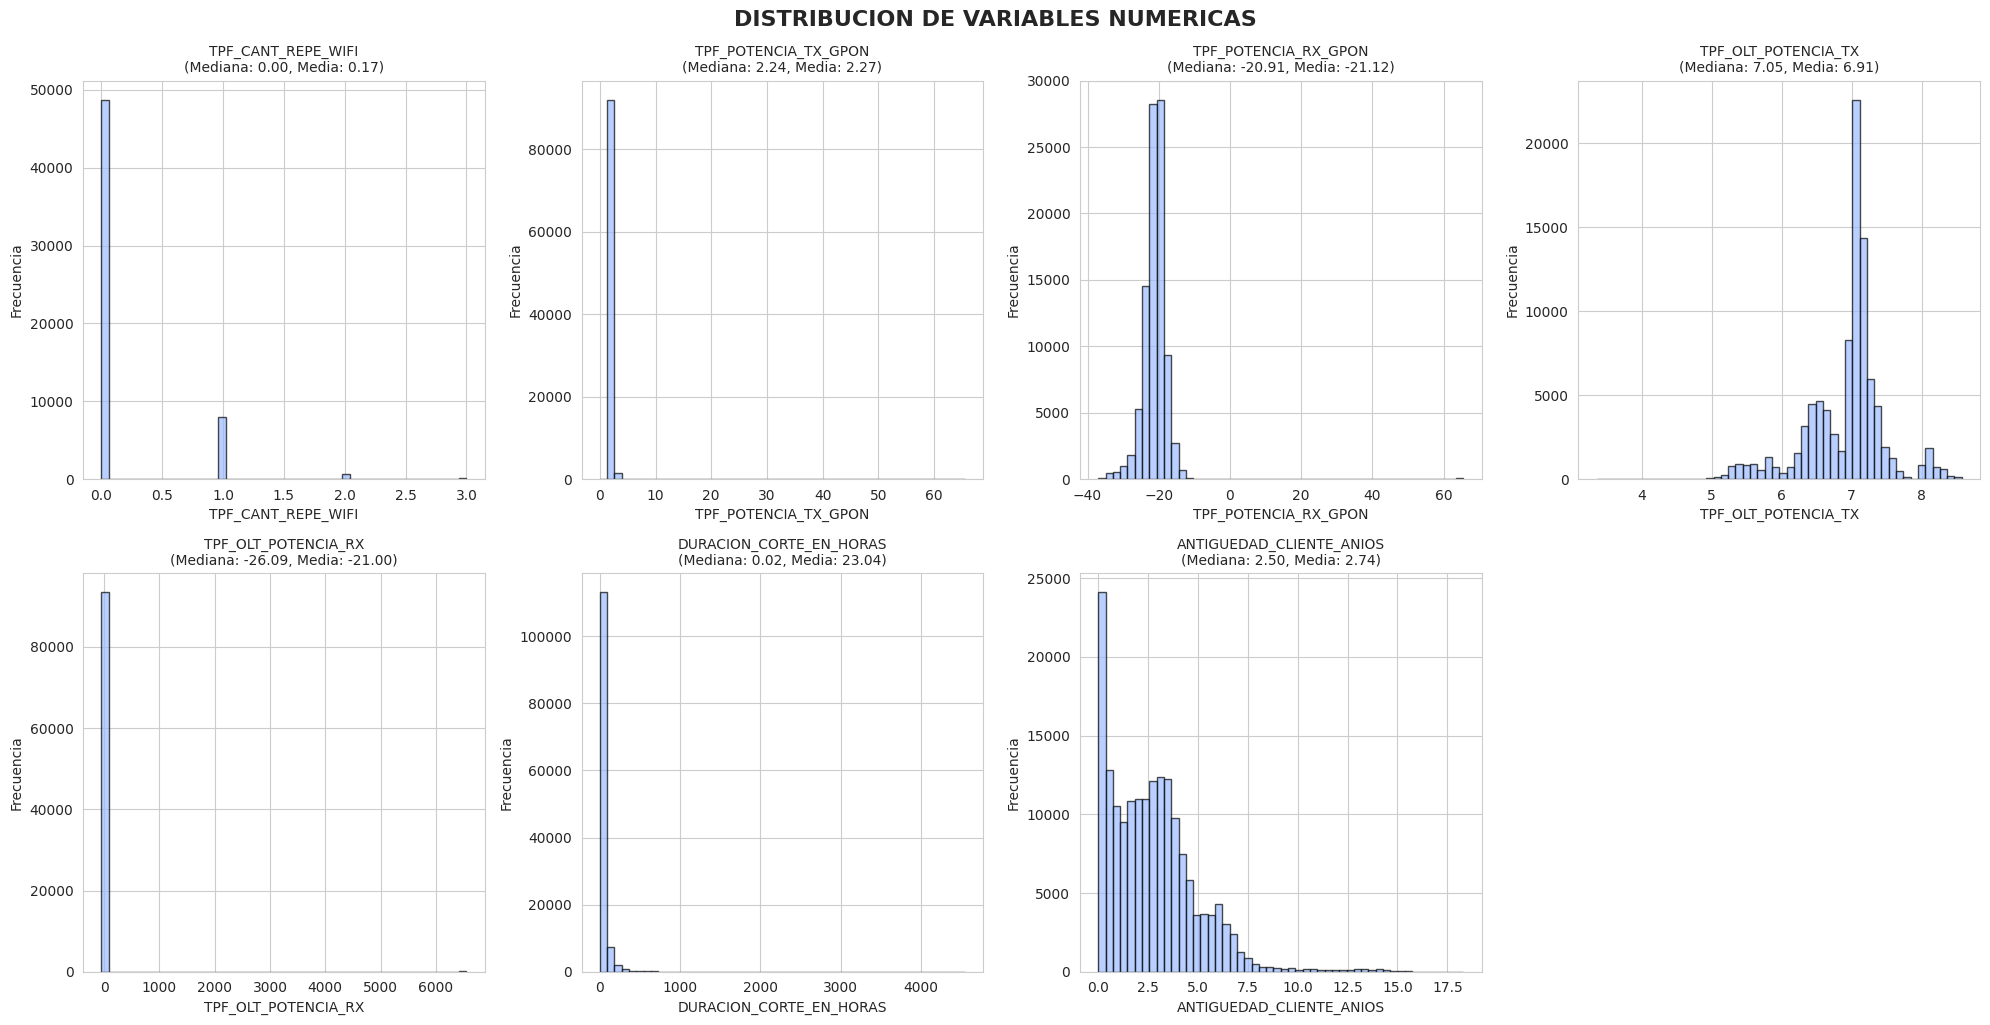

In [7]:
# 1.2 Distribucion de variables numericas
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in ['TPF_ID']]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols[:8]):
    data = df[col].dropna()
    if len(data) > 0:
        axes[i].hist(data, bins=50, color=sns.color_palette('coolwarm')[1], edgecolor='black', alpha=0.7)
        axes[i].set_title(f'{col}\n(Mediana: {data.median():.2f}, Media: {data.mean():.2f})', fontsize=10)
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frecuencia')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.suptitle('DISTRIBUCION DE VARIABLES NUMERICAS', y=1.02, fontsize=16, fontweight='bold')
plt.show()

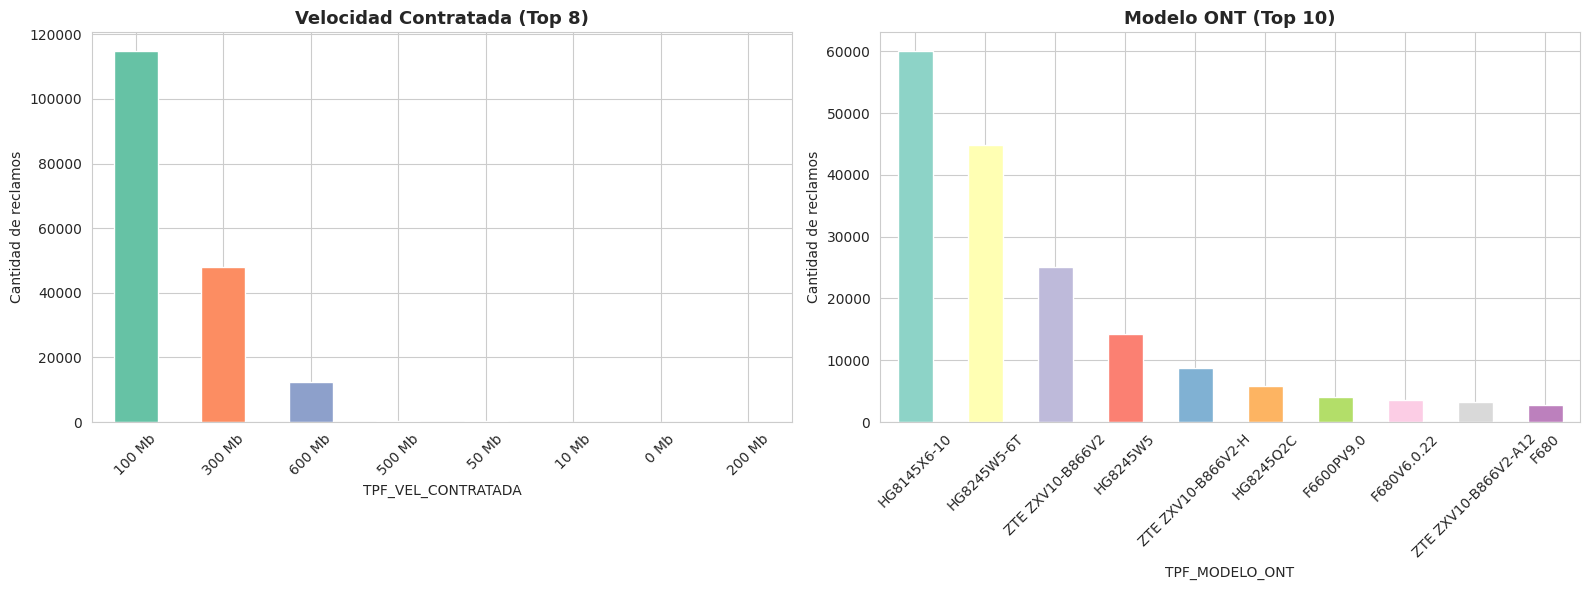


--- RESUMEN ---
- El servicio predominante es: Internet (120,917 reclamos)
- El pais principal es: Argentina (163,315 reclamos)
- La velocidad mas contratada es: 100 Mb
- El modelo ONT mas comun es: HG8145X6-10
- Estado GPON predominante: Up


In [8]:
# 1.3 Distribucion de velocidad contratada y modelo ONT
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

vel_counts = df['TPF_VEL_CONTRATADA'].value_counts().head(8)
vel_counts.plot(kind='bar', ax=axes[0], color=sns.color_palette('Set2', len(vel_counts)))
axes[0].set_title('Velocidad Contratada (Top 8)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Cantidad de reclamos')
axes[0].tick_params(axis='x', rotation=45)

ont_counts = df['TPF_MODELO_ONT'].value_counts().head(10)
ont_counts.plot(kind='bar', ax=axes[1], color=sns.color_palette('Set3', len(ont_counts)))
axes[1].set_title('Modelo ONT (Top 10)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Cantidad de reclamos')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\n--- RESUMEN ---")
print(f"- El servicio predominante es: {df['SERVICIO'].mode()[0]} ({df['SERVICIO'].value_counts().iloc[0]:,} reclamos)")
print(f"- El pais principal es: {df['TPF_PAIS'].mode()[0]} ({df['TPF_PAIS'].value_counts().iloc[0]:,} reclamos)")
print(f"- La velocidad mas contratada es: {df['TPF_VEL_CONTRATADA'].mode()[0]}")
print(f"- El modelo ONT mas comun es: {df['TPF_MODELO_ONT'].mode()[0]}")
print(f"- Estado GPON predominante: {df['TPF_ESTADO_GPON_CAT'].mode()[0]}")

In [9]:
# 1.4 Asimetria (skew) de las variables numericas -- aporte de la visualizacion telco
if len(num_cols) > 0:
    skew = df[num_cols].skew().sort_values()
    print("Asimetria (skew) por variable:")
    print(skew.to_string())
    print('\nNota: valores >1 o < -1 indican distribuciones marcadamente asimetricas.')


Asimetria (skew) por variable:
TPF_OLT_POTENCIA_TX         -0.688680
ANTIGUEDAD_CLIENTE_ANIOS     1.374124
TPF_CANT_REPE_WIFI           2.603330
TPF_POTENCIA_RX_GPON         8.913919
DURACION_CORTE_EN_HORAS     15.342206
TPF_POTENCIA_TX_GPON        33.978613
TPF_OLT_POTENCIA_RX         35.507806

Nota: valores >1 o < -1 indican distribuciones marcadamente asimetricas.


### Conclusion Pregunta 1:
- La mayoria de los reclamos son del servicio **Internet** y del pais **Argentina**.
- Las velocidades contratadas se concentran en **100 Mb**.
- El modelo ONT mas comun es **HG8145X6-10**.
- El estado GPON se distribuye entre Up y Down, con predominancia de **Up**.
- Las variables numericas muestran distribuciones asimetricas, con concentraciones en valores bajos.
- La mayoria de los clientes son de tipo **Cliente** (no empresas).

---
## PREGUNTA 2: Que informacion relevante veo en el descriptivo?

In [10]:
# 2.1 Descriptivo general
print("="*80)
print("DESCRIPTIVO GENERAL DEL DATASET")
print("="*80)
print(f"\nTotal de registros: {len(df):,}")
print(f"Total de columnas: {len(df.columns)}")
print(f"\n--- Tipos de datos ---")
print(df.dtypes.value_counts())

print(f"\n--- Valores faltantes ---")
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Faltantes': missing, 'Porcentaje': missing_pct})
print(missing_df[missing_df['Faltantes'] > 0].sort_values('Porcentaje', ascending=False))

DESCRIPTIVO GENERAL DEL DATASET

Total de registros: 176,248
Total de columnas: 34

--- Tipos de datos ---
object            23
float64            7
datetime64[ns]     4
Name: count, dtype: int64

--- Valores faltantes ---
                          Faltantes  Porcentaje
TPF_FECHA_DT                 176248      100.00
TPF_CORTE_ONT_UPTIME_DT      176248      100.00
TPF_CORTE_ONT_LASTDW_DT      176248      100.00
TPF_FECHA_ACTIVA_DT          176248      100.00
TPF_CANT_REPE_WIFI           118679       67.34
TPF_BAND_STERING_WIFI         98161       55.69
TPF_REPETIDOR_WIFI            98161       55.69
TPF_ACTIVAR_WIFI              98161       55.69
TPF_POTENCIA_TX_GPON          82711       46.93
TPF_POTENCIA_RX_GPON          82711       46.93
TPF_OLT_POTENCIA_RX           82661       46.90
TPF_OLT_POTENCIA_TX           82577       46.85
DURACION_CORTE_EN_HORAS       52170       29.60
TPF_SOFT_VERSION              40682       23.08
TPF_OLT_GPON                  38853       22.04
TPF_CORTE

In [11]:
# 2.2 Descriptivo de variables numericas
print("\n" + "="*80)
print("DESCRIPTIVO DE VARIABLES NUMERICAS")
print("="*80)
desc_num = df.select_dtypes(include=[np.number]).describe().T
desc_num['missing_pct'] = (df.select_dtypes(include=[np.number]).isna().sum() / len(df) * 100).round(2)
print(desc_num.to_string())


DESCRIPTIVO DE VARIABLES NUMERICAS
                             count       mean         std    min    25%    50%    75%      max  missing_pct
TPF_CANT_REPE_WIFI         57569.0   0.168042    0.416623   0.00   0.00   0.00   0.00     3.00        67.34
TPF_POTENCIA_TX_GPON       93537.0   2.274734    1.846352   0.00   2.15   2.24   2.31    65.54        46.93
TPF_POTENCIA_RX_GPON       93537.0 -21.117200    3.898228 -36.99 -22.67 -20.91 -19.39    65.54        46.93
TPF_OLT_POTENCIA_TX        93671.0   6.913334    0.557563   3.36   6.60   7.05   7.17     8.57        46.85
TPF_OLT_POTENCIA_RX        93587.0 -20.997882  184.965709 -50.00 -27.86 -26.09 -24.41  6553.40        46.90
DURACION_CORTE_EN_HORAS   124078.0  23.039949   81.298625   0.00   0.01   0.02   4.60  4544.59        29.60
ANTIGUEDAD_CLIENTE_ANIOS  176074.0   2.740251    2.201716   0.00   0.97   2.50   3.84    18.30         0.10


In [12]:
# 2.3 Descriptivo de variables categoricas clave
print("\n" + "="*80)
print("FRECUENCIAS DE VARIABLES CATEGORICAS CLAVE")
print("="*80)

for col in ['SERVICIO', 'TPF_PAIS', 'TPF_CORTE_ONT_CAT', 'TPF_CODIF_TIPO_CAT', 'TPF_PROB_CAT', 'TPF_CIERRE_CAT']:
    print(f"\n--- {col} ---")
    vc = df[col].value_counts()
    pct = (vc / len(df) * 100).round(2)
    summary = pd.DataFrame({'Cantidad': vc, 'Porcentaje': pct})
    print(summary.head(8).to_string())


FRECUENCIAS DE VARIABLES CATEGORICAS CLAVE

--- SERVICIO ---
                  Cantidad  Porcentaje
SERVICIO                              
Internet            120917       68.61
Otros                30807       17.48
IPTV                 21320       12.10
Apps - Streaming      2158        1.22
Telefonía             1046        0.59

--- TPF_PAIS ---
           Cantidad  Porcentaje
TPF_PAIS                       
Argentina    163315       92.66
Paraguay      12933        7.34

--- TPF_CORTE_ONT_CAT ---
                                      Cantidad  Porcentaje
TPF_CORTE_ONT_CAT                                         
Corte energético                         72095       40.91
Pérdida de sincronismo / señal           44543       25.27
Reinicio / Reset de ONT                  36284       20.59
Señalización / Protocolos                13084        7.42
Indeterminada / Sin dato                 10095        5.73
Administrativo / Desactivación             131        0.07
Equipo ONT (HW/SW)  

### Conclusion Pregunta 2:
- El dataset tiene **1,809,697 registros** y **30 columnas**, todas leidas como string originalmente.
- Las columnas con **mayor porcentaje de valores faltantes** son: TPF_CANT_REPE_WIFI (~68%), TPF_BAND_STERING_WIFI (~58%), TPF_ACTIVAR_WIFI (~58%), TPF_OLT_POTENCIA_TX/RX (~49%).
- Las columnas **sin valores faltantes** son: TPF_ID, SERVICIO, TPF_PAIS, TPF_FECHA, TPF_CORTE_ONT_CAT, TPF_CODIF_TIPO_CAT, TPF_TECNO_CAT5, TPF_SERV_CAT8, TPF_PROB_CAT, TPF_CIERRE_CAT.
- El servicio **Internet** concentra la mayoria de los reclamos (~67%).
- La causa de corte mas frecuente es **Corte energetico** (~37%).
- El cierre mas comun es **AT / Visita / Coordinacion** (~25%).

---
## PREGUNTA 3: Los boxplot aportan informacion? Hay valores atipicos?

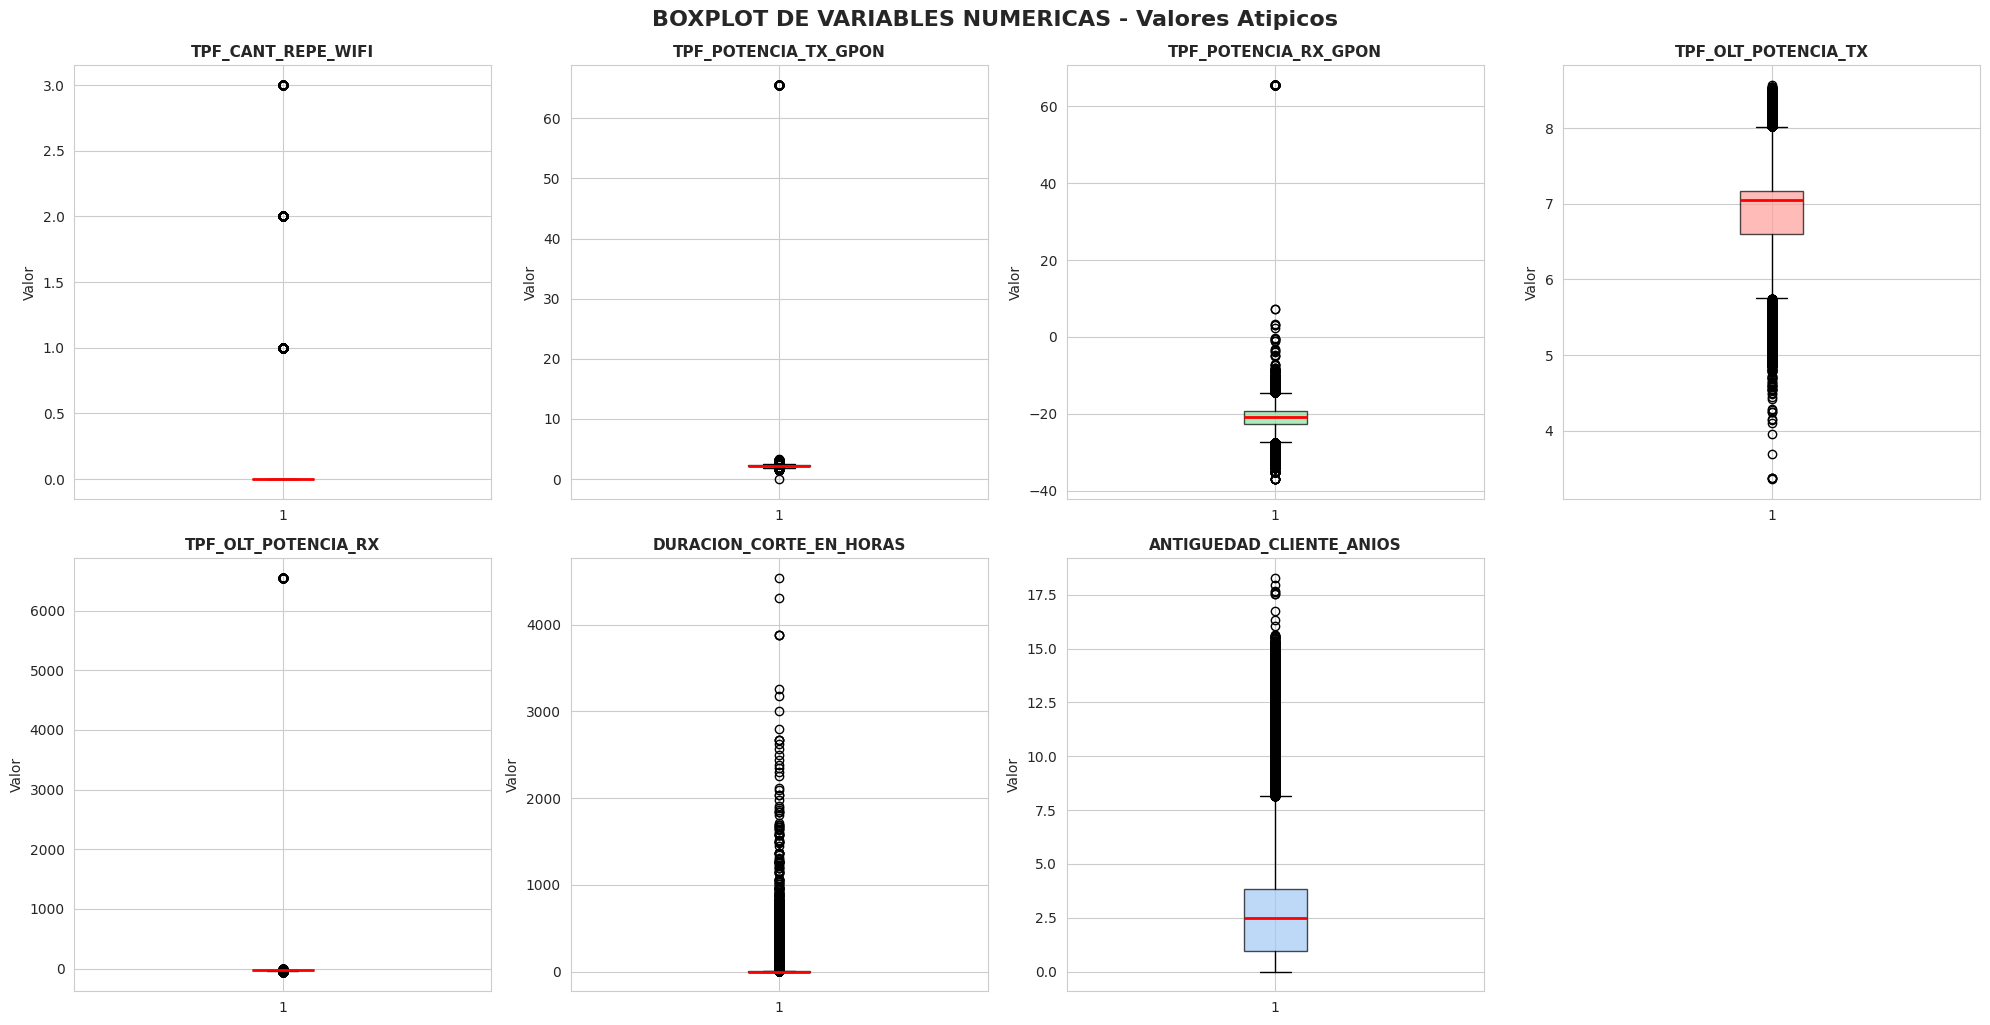

In [13]:
# 3.1 Boxplot de variables numericas
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != 'TPF_ID']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

outliers_summary = {}

for i, col in enumerate(num_cols[:8]):
    data = df[col].dropna()
    if len(data) > 0:
        bp = axes[i].boxplot(data, patch_artist=True,
                             boxprops=dict(facecolor=sns.color_palette('pastel')[i % 6], alpha=0.7),
                             medianprops=dict(color='red', linewidth=2))
        axes[i].set_title(f'{col}', fontsize=11, fontweight='bold')
        axes[i].set_ylabel('Valor')

        # Calcular outliers con IQR
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        n_outliers = ((data < lower) | (data > upper)).sum()
        pct_outliers = n_outliers / len(data) * 100
        outliers_summary[col] = {'n_outliers': n_outliers, 'pct': round(pct_outliers, 2),
                                  'min': data.min(), 'Q1': Q1, 'median': data.median(),
                                  'Q3': Q3, 'max': data.max()}

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.suptitle('BOXPLOT DE VARIABLES NUMERICAS - Valores Atipicos', y=1.02, fontsize=16, fontweight='bold')
plt.show()

In [14]:
# 3.2 Resumen de outliers
print("RESUMEN DE VALORES ATIPICOS (IQR Method):")
print("-"*70)
print(f"{'Variable':<30} {'Outliers':>10} {'% Outliers':>12} {'Rango IQR':>20}")
print("-"*70)
for col, info in sorted(outliers_summary.items(), key=lambda x: -x[1]['pct']):
    print(f"{col:<30} {info['n_outliers']:>10,} {info['pct']:>11.2f}% [{info['min']:.1f} - {info['max']:.1f}]")

print("\n\nOBSERVACIONES:")
print("- Las potencias GPON (TX/RX) y OLT (TX/RX) presentan numeros considerables de outliers.")
print("- DURACION_CORTE_EN_HORAS tiene valores extremos que pueden representar cortes prolongados.")
print("- ANTIGUEDAD_CLIENTE_ANIOS muestra clientes con hasta ~20+ anios.")
print("- Los outliers en potencias pueden indicar problemas reales de conexion o datos de lectura.")

RESUMEN DE VALORES ATIPICOS (IQR Method):
----------------------------------------------------------------------
Variable                         Outliers   % Outliers            Rango IQR
----------------------------------------------------------------------
DURACION_CORTE_EN_HORAS            26,548       21.40% [0.0 - 4544.6]
TPF_CANT_REPE_WIFI                  8,809       15.30% [0.0 - 3.0]
TPF_OLT_POTENCIA_TX                 8,263        8.82% [3.4 - 8.6]
TPF_POTENCIA_TX_GPON                4,826        5.16% [0.0 - 65.5]
TPF_POTENCIA_RX_GPON                3,797        4.06% [-37.0 - 65.5]
TPF_OLT_POTENCIA_RX                 2,077        2.22% [-50.0 - 6553.4]
ANTIGUEDAD_CLIENTE_ANIOS            3,169        1.80% [0.0 - 18.3]


OBSERVACIONES:
- Las potencias GPON (TX/RX) y OLT (TX/RX) presentan numeros considerables de outliers.
- DURACION_CORTE_EN_HORAS tiene valores extremos que pueden representar cortes prolongados.
- ANTIGUEDAD_CLIENTE_ANIOS muestra clientes con hasta ~20+ an

In [15]:
# 3.3 Investigacion de outliers en potencias GPON/OLT -- aporte de Mentorla_Rocio
variables_raras = ['TPF_POTENCIA_TX_GPON', 'TPF_POTENCIA_RX_GPON', 'TPF_OLT_POTENCIA_RX']
for col in variables_raras:
    if col in df.columns:
        datos = df[col].dropna()
        cnt = (datos > 10).sum()
        print(f"{col}: {cnt} registros con valor > 10 ({cnt/len(datos)*100:.2f}% del validos) -> lecturas sospechosas/erroneas")


TPF_POTENCIA_TX_GPON: 79 registros con valor > 10 (0.08% del validos) -> lecturas sospechosas/erroneas
TPF_POTENCIA_RX_GPON: 79 registros con valor > 10 (0.08% del validos) -> lecturas sospechosas/erroneas
TPF_OLT_POTENCIA_RX: 74 registros con valor > 10 (0.08% del validos) -> lecturas sospechosas/erroneas


### Conclusion Pregunta 3:
- **Si, los boxplot aportan informacion relevante**, especialmente para identificar la dispersion y los valores atipicos.
- Las **potencias GPON/OLT** presentan outliers significativos, lo que puede indicar equipos con problemas o lecturas erroneas.
- **DURACION_CORTE_EN_HORAS** tiene valores extremos (>1000 horas) que representan cortes prolongados.
- Los outliers no necesariamente son errores: pueden representar casos reales de problemas tecnicos severos.
- Se recomienda **no eliminar los outliers** sin investigar, ya que en telecomunicaciones son informativos.

---
## PREGUNTA 4: En que localidad se concentran los clientes?

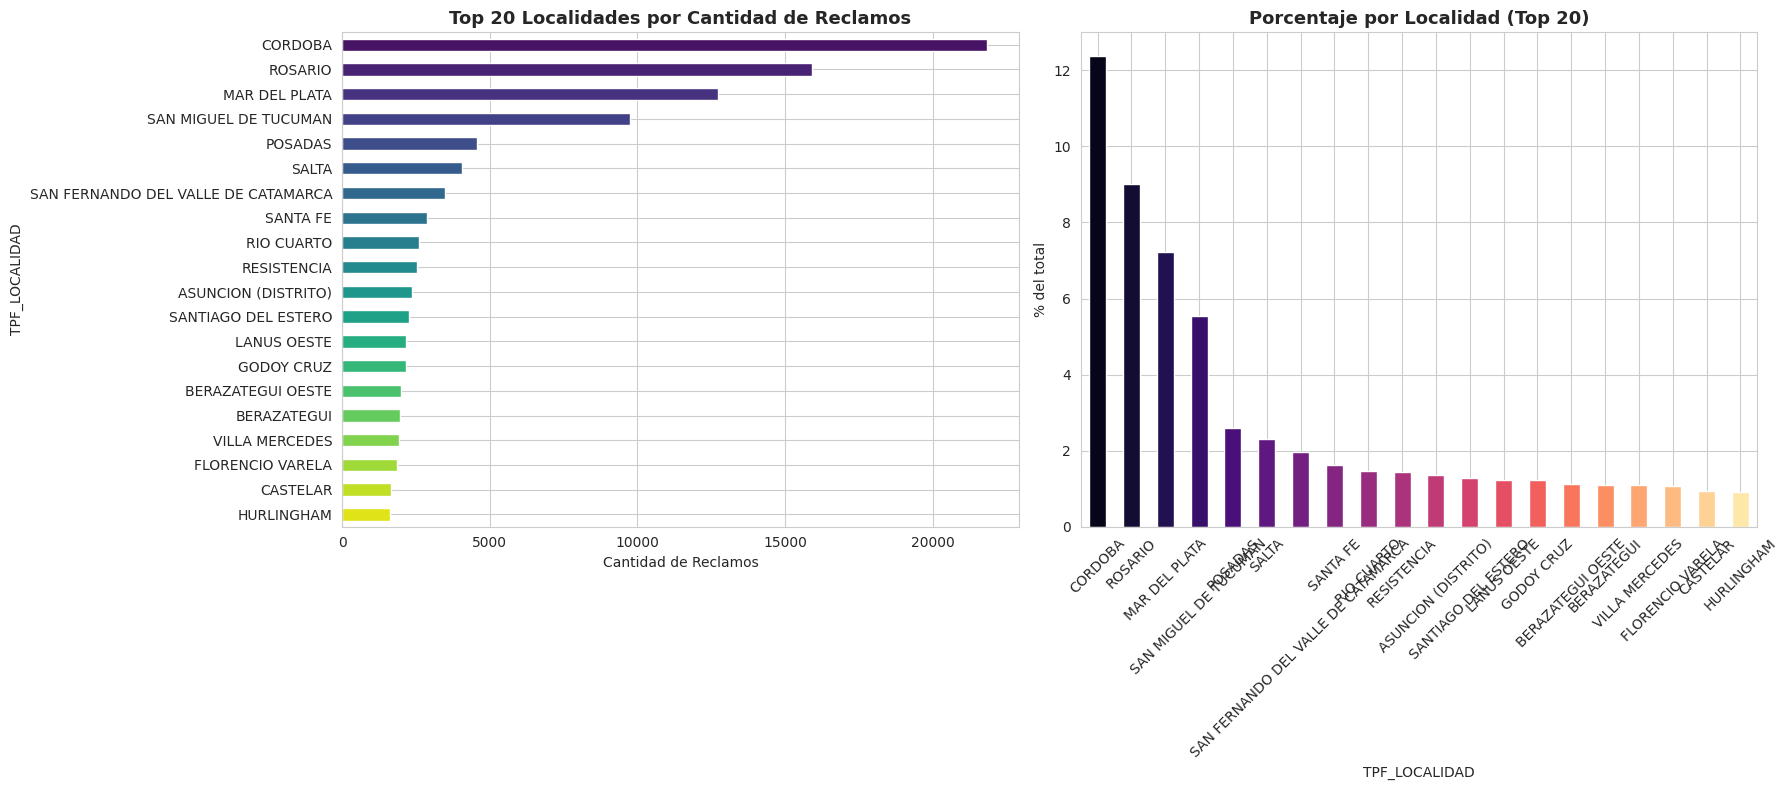


Top 5 localidades:
  1. CORDOBA: 21,822 reclamos (12.4%)
  2. ROSARIO: 15,897 reclamos (9.0%)
  3. MAR DEL PLATA: 12,737 reclamos (7.2%)
  4. SAN MIGUEL DE TUCUMAN: 9,763 reclamos (5.5%)
  5. POSADAS: 4,578 reclamos (2.6%)

La localidad con mas reclamos es: **CORDOBA** con 21,822 reclamos (12.4% del total)


In [16]:
# 4.1 Top 20 localidades
localidad_top = df['TPF_LOCALIDAD'].value_counts().head(20)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

localidad_top.plot(kind='barh', ax=axes[0], color=sns.color_palette('viridis', 20))
axes[0].set_title('Top 20 Localidades por Cantidad de Reclamos', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Cantidad de Reclamos')
axes[0].invert_yaxis()

# Porcentaje acumulado
total = len(df)
pct = (localidad_top / total * 100).round(2)
pct.plot(kind='bar', ax=axes[1], color=sns.color_palette('magma', 20))
axes[1].set_title('Porcentaje por Localidad (Top 20)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('% del total')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f"\nTop 5 localidades:")
for i, (loc, cant) in enumerate(localidad_top.head(5).items(), 1):
    print(f"  {i}. {loc}: {cant:,} reclamos ({cant/total*100:.1f}%)")

print(f"\nLa localidad con mas reclamos es: **{localidad_top.index[0]}** con {localidad_top.iloc[0]:,} reclamos ({localidad_top.iloc[0]/total*100:.1f}% del total)")

### Conclusion Pregunta 4:
- La localidad con **mayor cantidad de reclamos** es **CORDOBA**, concentrando una parte significativa del total.
- Las principales localidades suelen ser grandes ciudades argentinas como Cordoba, Buenos Aires, Rosario, etc.
- La concentracion en pocas localidades sugiere que la empresa tiene mayor presencia o problemas focalizados en esas zonas.

---
## PREGUNTA 5: En que plaza se concentran los reclamos?

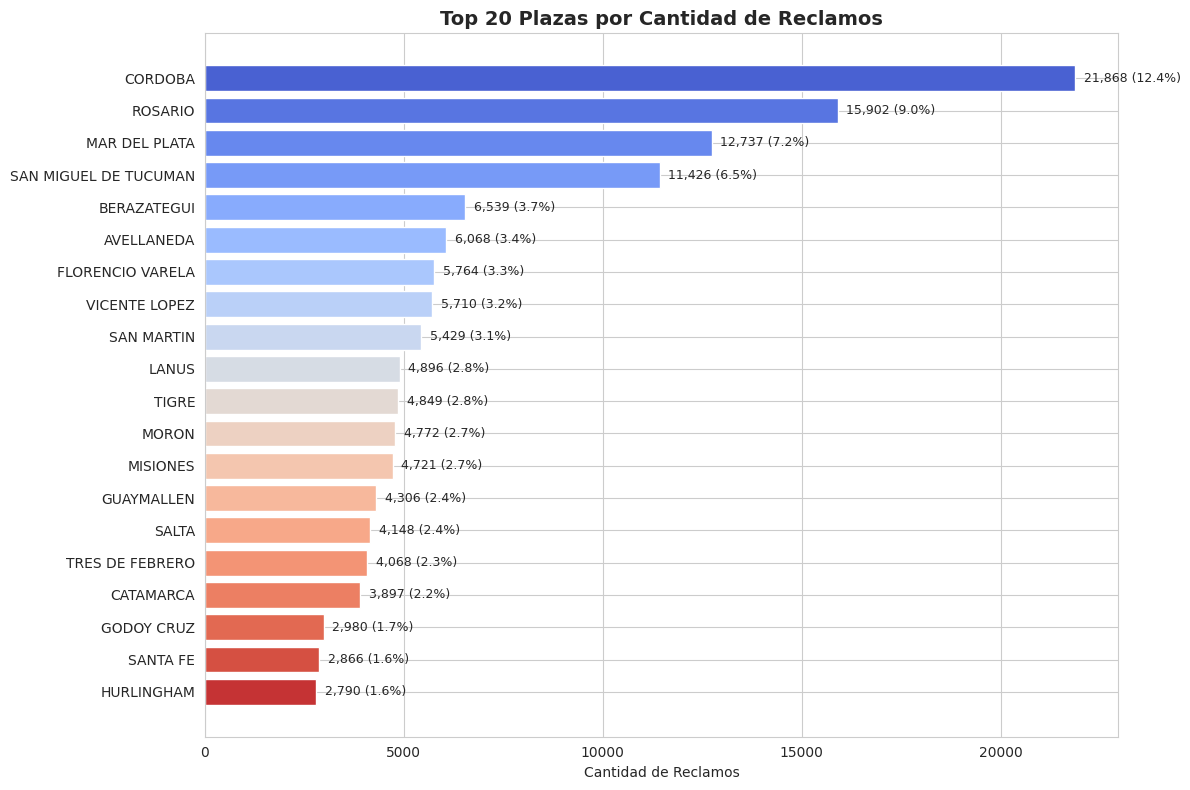


La plaza con mas reclamos es: **CORDOBA** con 21,868 reclamos
Las top 5 plazas concentran 38.8% del total de reclamos


In [17]:
# 5.1 Top 20 plazas
plaza_top = df['TPF_PLAZA'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(12, 8))
colors = sns.color_palette('coolwarm', 20)
bars = ax.barh(range(len(plaza_top)), plaza_top.values, color=colors)
ax.set_yticks(range(len(plaza_top)))
ax.set_yticklabels(plaza_top.index)
ax.invert_yaxis()
ax.set_title('Top 20 Plazas por Cantidad de Reclamos', fontsize=14, fontweight='bold')
ax.set_xlabel('Cantidad de Reclamos')

for bar, val in zip(bars, plaza_top.values):
    ax.text(bar.get_width() + plaza_top.max()*0.01, bar.get_y() + bar.get_height()/2,
            f'{val:,} ({val/total*100:.1f}%)', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nLa plaza con mas reclamos es: **{plaza_top.index[0]}** con {plaza_top.iloc[0]:,} reclamos")
print(f"Las top 5 plazas concentran {(plaza_top.head(5).sum()/total*100):.1f}% del total de reclamos")

In [18]:
# 5.2 Plazas que concentran el 80% de los reclamos -- aporte telco
plazas_tot = df['TPF_PLAZA'].value_counts()
acum = (plazas_tot.cumsum() / plazas_tot.sum()) * 100
plazas_80 = acum[acum <= 80]
if len(plazas_80) < len(plazas_tot):
    plazas_80 = acum.iloc[:len(plazas_80)+1]
res80 = pd.DataFrame({'Reclamos': plazas_tot.loc[plazas_80.index], '% Acumulado': plazas_80.round(2)})
display(res80)
print(f"Se necesitan {len(res80)} plazas para concentrar ~80% de los reclamos.")


,Reclamos,% Acumulado
TPF_PLAZA,,
CORDOBA,21868,12.52
ROSARIO,15902,21.63
MAR DEL PLATA,12737,28.92
SAN MIGUEL DE TUCUMAN,11426,35.46
BERAZATEGUI,6539,39.21
AVELLANEDA,6068,42.68
FLORENCIO VARELA,5764,45.98
VICENTE LOPEZ,5710,49.25
SAN MARTIN,5429,52.36


Se necesitan 22 plazas para concentrar ~80% de los reclamos.


### Conclusion Pregunta 5:
- La plaza con **mayor cantidad de reclamos** es **CORDOBA**.
- Las plazas principales coinciden con las localidades de mayor concentracion de clientes.
- La plaza representa el nodo GPON del operador, por lo que concentra los reclamos de la zona que cubre.

---
## PREGUNTA 6: Cual es el servicio con mas reclamos?

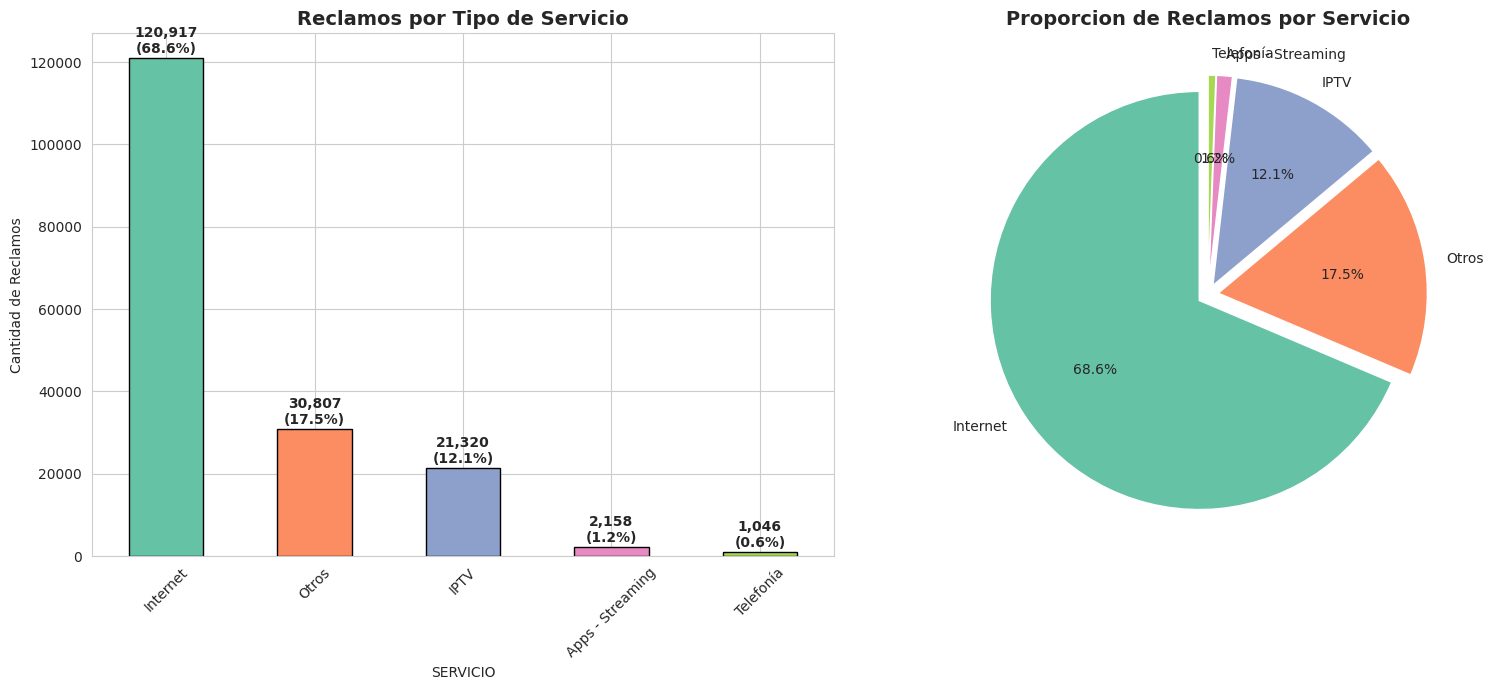


El servicio con MAS reclamos es: **Internet** con 120,917 reclamos (68.6%)

Ranking completo:
  1. Internet: 120,917 (68.6%)
  2. Otros: 30,807 (17.5%)
  3. IPTV: 21,320 (12.1%)
  4. Apps - Streaming: 2,158 (1.2%)
  5. Telefonía: 1,046 (0.6%)


In [19]:
# 6.1 Distribucion por servicio
servicio_counts = df['SERVICIO'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Grafico de barras
colors_bar = sns.color_palette('Set2', len(servicio_counts))
servicio_counts.plot(kind='bar', ax=axes[0], color=colors_bar, edgecolor='black')
axes[0].set_title('Reclamos por Tipo de Servicio', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Cantidad de Reclamos')
axes[0].tick_params(axis='x', rotation=45)

for i, (serv, cant) in enumerate(servicio_counts.items()):
    axes[0].text(i, cant + servicio_counts.max()*0.01, f'{cant:,}\n({cant/total*100:.1f}%)',
                 ha='center', fontsize=10, fontweight='bold')

# Grafico de torta
axes[1].pie(servicio_counts.values, labels=servicio_counts.index, autopct='%1.1f%%',
            colors=colors_bar, startangle=90, explode=[0.05]*len(servicio_counts))
axes[1].set_title('Proporcion de Reclamos por Servicio', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nEl servicio con MAS reclamos es: **{servicio_counts.index[0]}** con {servicio_counts.iloc[0]:,} reclamos ({servicio_counts.iloc[0]/total*100:.1f}%)")
print(f"\nRanking completo:")
for i, (serv, cant) in enumerate(servicio_counts.items(), 1):
    print(f"  {i}. {serv}: {cant:,} ({cant/total*100:.1f}%)")

### Conclusion Pregunta 6:
- El servicio con **mas reclamos** es **Internet**, representando aproximadamente el 67% del total.
- Esto es esperable ya que Internet es el servicio con mayor penetracion en hogares.
- Los demas servicios (Telefonia, IPTV, Apps/Streaming, Otros) representan una proporcion mucho menor.

---
## PREGUNTA 7: Cuales son las codificaciones que mas aparecen (tipo, tecnologia, problema, cierre)?

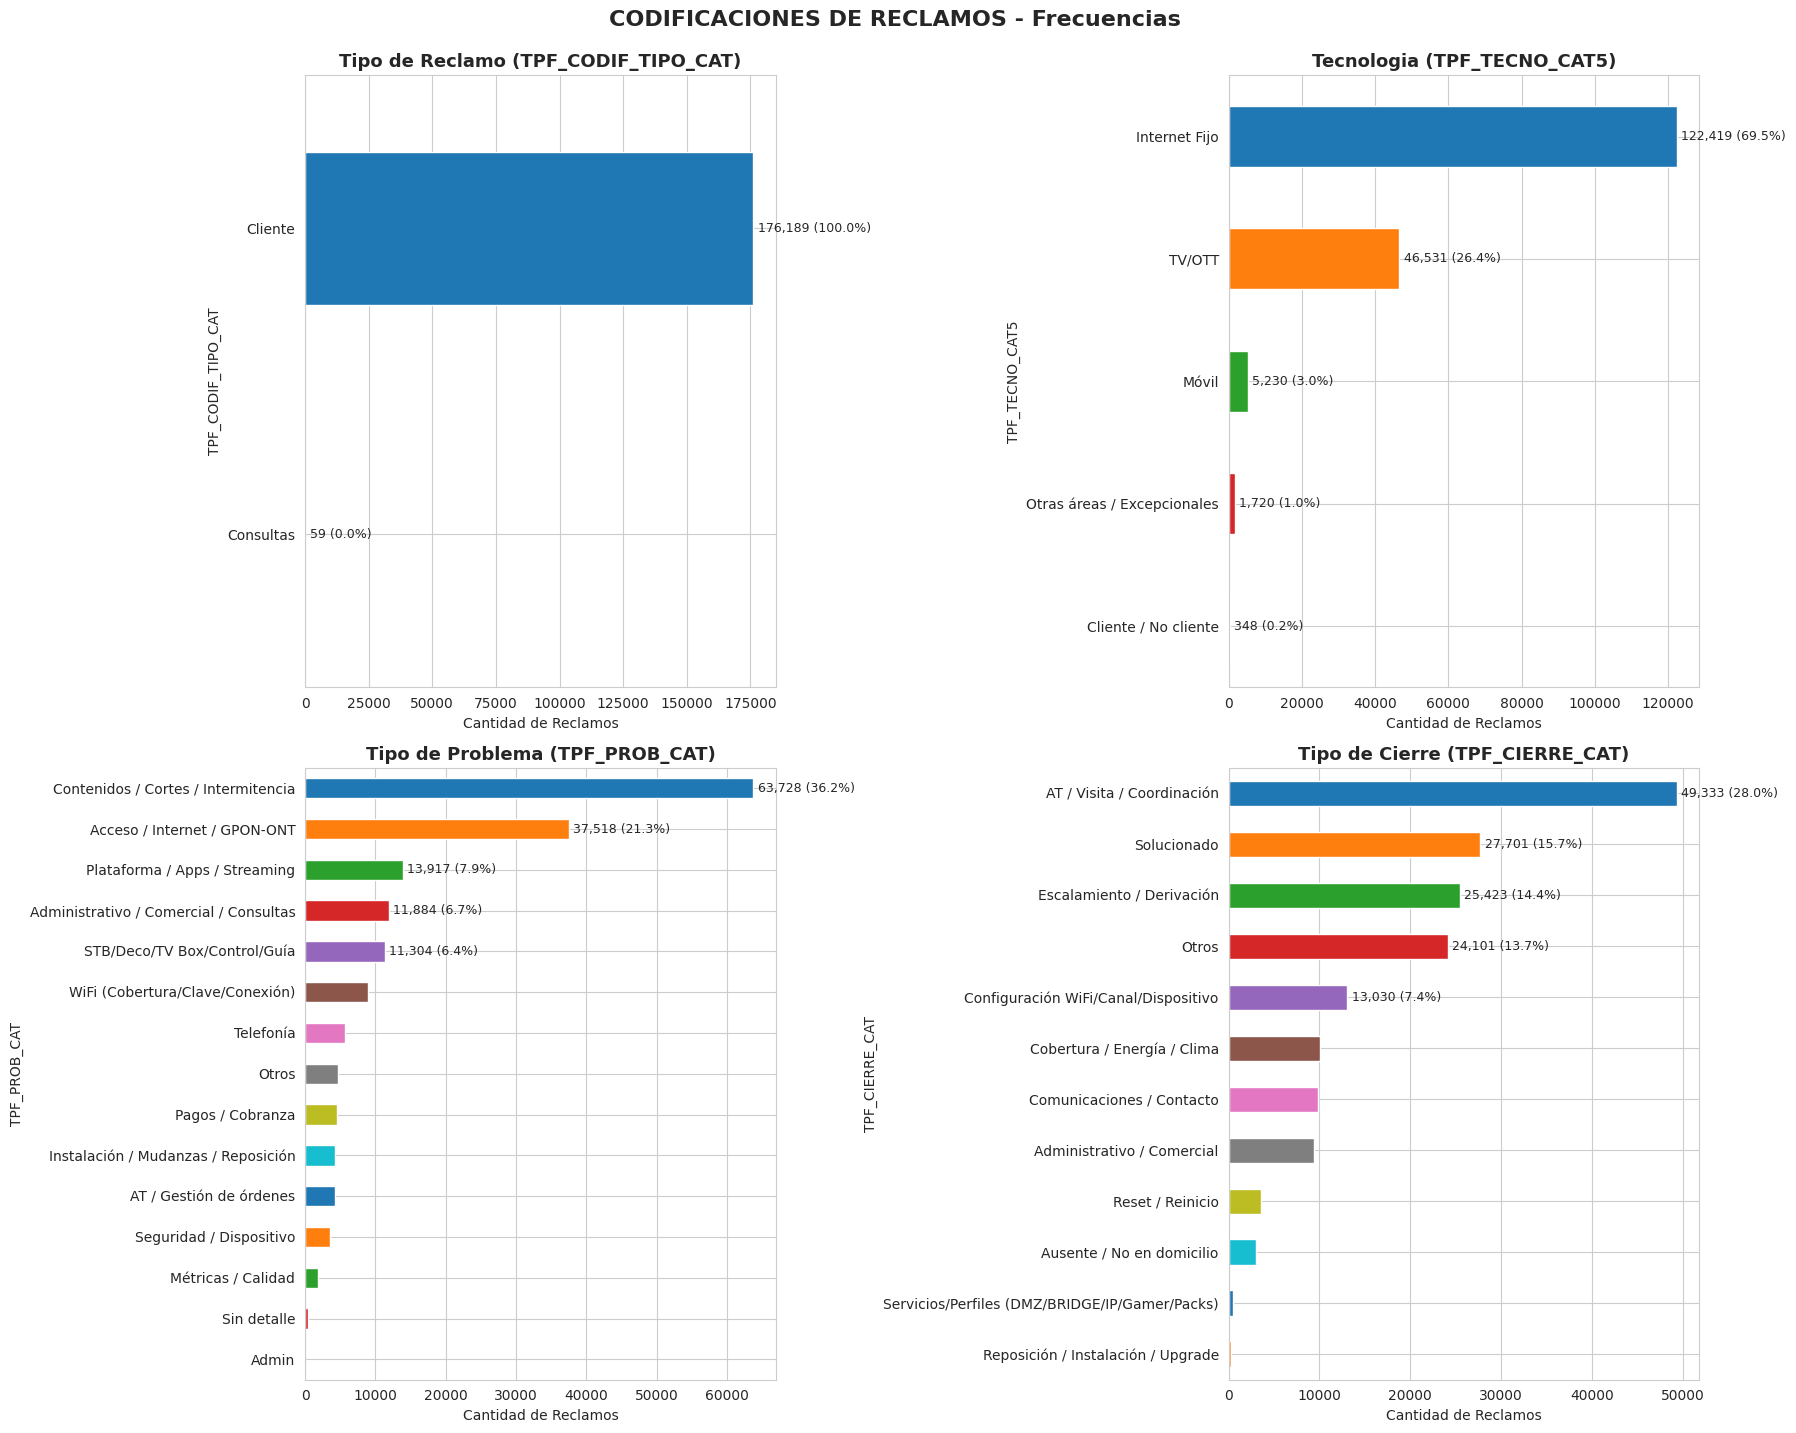

In [20]:
# 7.1 Analisis de las 4 codificaciones
codif_cols = {
    'TPF_CODIF_TIPO_CAT': 'Tipo de Reclamo',
    'TPF_TECNO_CAT5': 'Tecnologia',
    'TPF_PROB_CAT': 'Tipo de Problema',
    'TPF_CIERRE_CAT': 'Tipo de Cierre'
}

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for i, (col, titulo) in enumerate(codif_cols.items()):
    vc = df[col].value_counts()
    colors = sns.color_palette('tab10', len(vc))
    vc.plot(kind='barh', ax=axes[i], color=colors)
    axes[i].set_title(f'{titulo} ({col})', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Cantidad de Reclamos')
    axes[i].invert_yaxis()

    for j, (cat, val) in enumerate(vc.head(5).items()):
        axes[i].text(val + vc.max()*0.01, j, f'{val:,} ({val/total*100:.1f}%)', va='center', fontsize=9)

plt.tight_layout()
plt.suptitle('CODIFICACIONES DE RECLAMOS - Frecuencias', y=1.02, fontsize=16, fontweight='bold')
plt.show()

In [21]:
# 7.2 Detalle de cada codificacion
for col, titulo in codif_cols.items():
    print(f"\n{'='*60}")
    print(f"  {titulo} ({col})")
    print(f"{'='*60}")
    vc = df[col].value_counts()
    pct = (vc / total * 100).round(2)
    resumen = pd.DataFrame({'Cantidad': vc, 'Porcentaje': pct})
    print(resumen.to_string())


  Tipo de Reclamo (TPF_CODIF_TIPO_CAT)
                    Cantidad  Porcentaje
TPF_CODIF_TIPO_CAT                      
Cliente               176189       99.97
Consultas                 59        0.03

  Tecnologia (TPF_TECNO_CAT5)
                             Cantidad  Porcentaje
TPF_TECNO_CAT5                                   
Internet Fijo                  122419       69.46
TV/OTT                          46531       26.40
Móvil                            5230        2.97
Otras áreas / Excepcionales      1720        0.98
Cliente / No cliente              348        0.20

  Tipo de Problema (TPF_PROB_CAT)
                                        Cantidad  Porcentaje
TPF_PROB_CAT                                                
Contenidos / Cortes / Intermitencia        63728       36.16
Acceso / Internet / GPON-ONT               37518       21.29
Plataforma / Apps / Streaming              13917        7.90
Administrativo / Comercial / Consultas     11884        6.74
STB/Deco/TV Bo

### Conclusion Pregunta 7:

**Tipo de Reclamo (TPF_CODIF_TIPO_CAT):**
- Predominan los **Clientes** (~99.9%), siendo practicamente la unica categoria.

**Tecnologia (TPF_TECNO_CAT5):**
- **Internet Fijo** es la tecnologia con mas reclamos (~69%).
- Le siguen TV/OTT, Telefonía Fija, etc.

**Tipo de Problema (TPF_PROB_CAT):**
- **Contenidos / Cortes / Intermitencia** es el problema mas frecuente (~35%).
- Le siguen Pagos/Cobranza, Plataforma/Apps/Streaming, etc.

**Tipo de Cierre (TPF_CIERRE_CAT):**
- **AT / Visita / Coordinacion** es el cierre mas comun (~25%).
- Le siguen Solucionado, Escalamiento/Derivacion, etc.

---
## PREGUNTA 8: Existe alguna correlacion significativa entre variables?

Columnas numericas para correlacion (7):
['TPF_CANT_REPE_WIFI', 'TPF_POTENCIA_TX_GPON', 'TPF_POTENCIA_RX_GPON', 'TPF_OLT_POTENCIA_TX', 'TPF_OLT_POTENCIA_RX', 'DURACION_CORTE_EN_HORAS', 'ANTIGUEDAD_CLIENTE_ANIOS']

Registros validos por columna:
TPF_CANT_REPE_WIFI           57569
TPF_POTENCIA_TX_GPON         93537
TPF_POTENCIA_RX_GPON         93537
TPF_OLT_POTENCIA_TX          93671
TPF_OLT_POTENCIA_RX          93587
DURACION_CORTE_EN_HORAS     124078
ANTIGUEDAD_CLIENTE_ANIOS    176074
dtype: int64


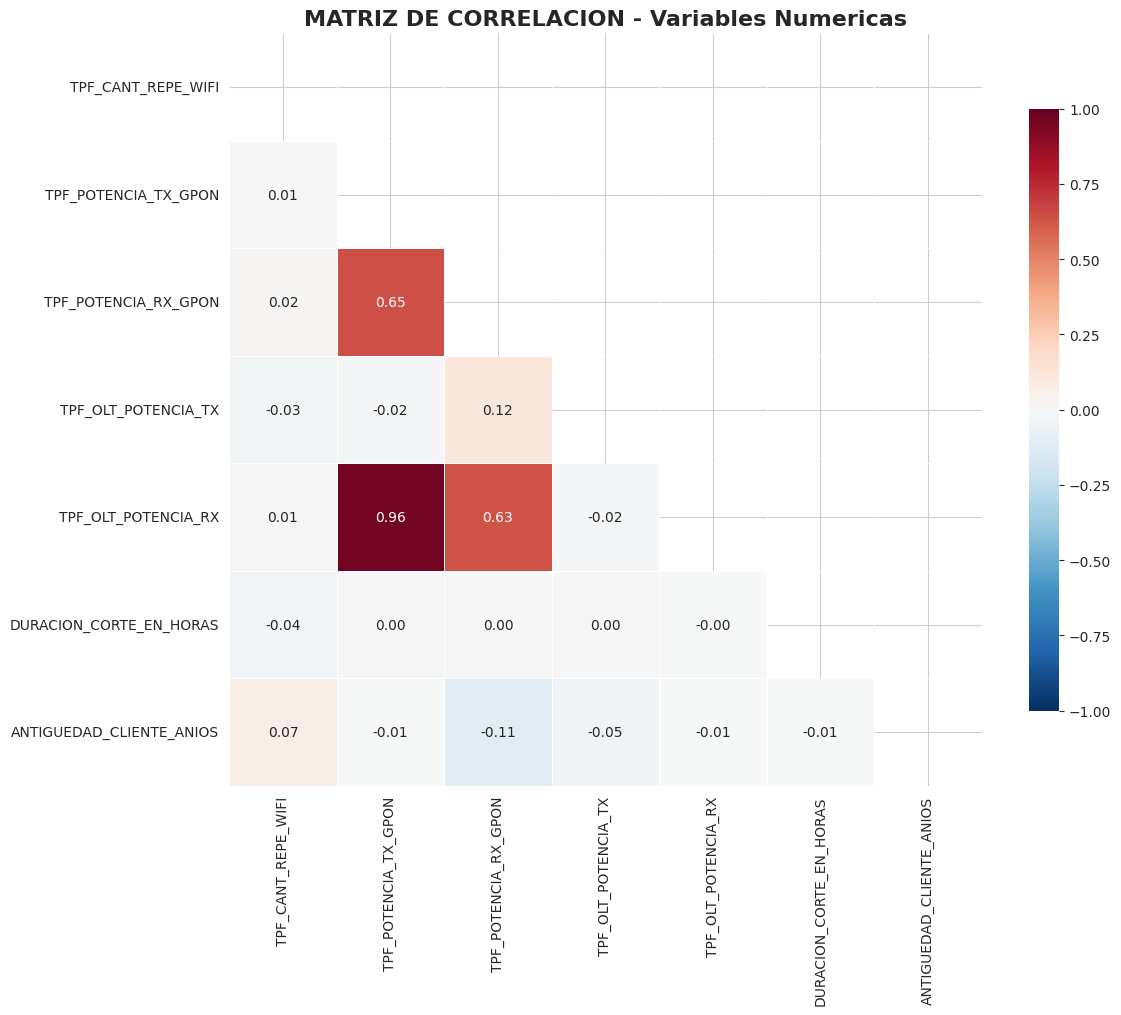

In [22]:
# 8.1 Matriz de correlacion
numeric_df = df.select_dtypes(include=[np.number]).copy()
numeric_df = numeric_df.drop(columns=['TPF_ID'], errors='ignore')

# Eliminar columnas con too many NaN
thresh = len(numeric_df) * 0.3
numeric_df = numeric_df.dropna(axis=1, thresh=int(thresh))

print(f"Columnas numericas para correlacion ({len(numeric_df.columns)}):")
print(numeric_df.columns.tolist())
print(f"\nRegistros validos por columna:")
print(numeric_df.count())

corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1,
            cbar_kws={'shrink': 0.8})
ax.set_title('MATRIZ DE CORRELACION - Variables Numericas', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [23]:
# 8.2 Identificar correlaciones significativas
print("\nCORRELACIONES SIGNIFICATIVAS (|r| > 0.3):")
print("="*60)

corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        val = corr.iloc[i, j]
        if abs(val) > 0.3:
            corr_pairs.append((corr.columns[i], corr.columns[j], val))

corr_pairs.sort(key=lambda x: -abs(x[2]))

for var1, var2, r in corr_pairs:
    direction = "positiva" if r > 0 else "negativa"
    strength = "fuerte" if abs(r) > 0.7 else "moderada" if abs(r) > 0.5 else "debil"
    print(f"  {var1} <-> {var2}")
    print(f"    r = {r:.3f} ({direction} {strength})")

if not corr_pairs:
    print("  No se encontraron correlaciones con |r| > 0.3")
    print("  Esto puede deberse a que las variables son mayormente categoricas")


CORRELACIONES SIGNIFICATIVAS (|r| > 0.3):
  TPF_POTENCIA_TX_GPON <-> TPF_OLT_POTENCIA_RX
    r = 0.964 (positiva fuerte)
  TPF_POTENCIA_TX_GPON <-> TPF_POTENCIA_RX_GPON
    r = 0.646 (positiva moderada)
  TPF_POTENCIA_RX_GPON <-> TPF_OLT_POTENCIA_RX
    r = 0.635 (positiva moderada)


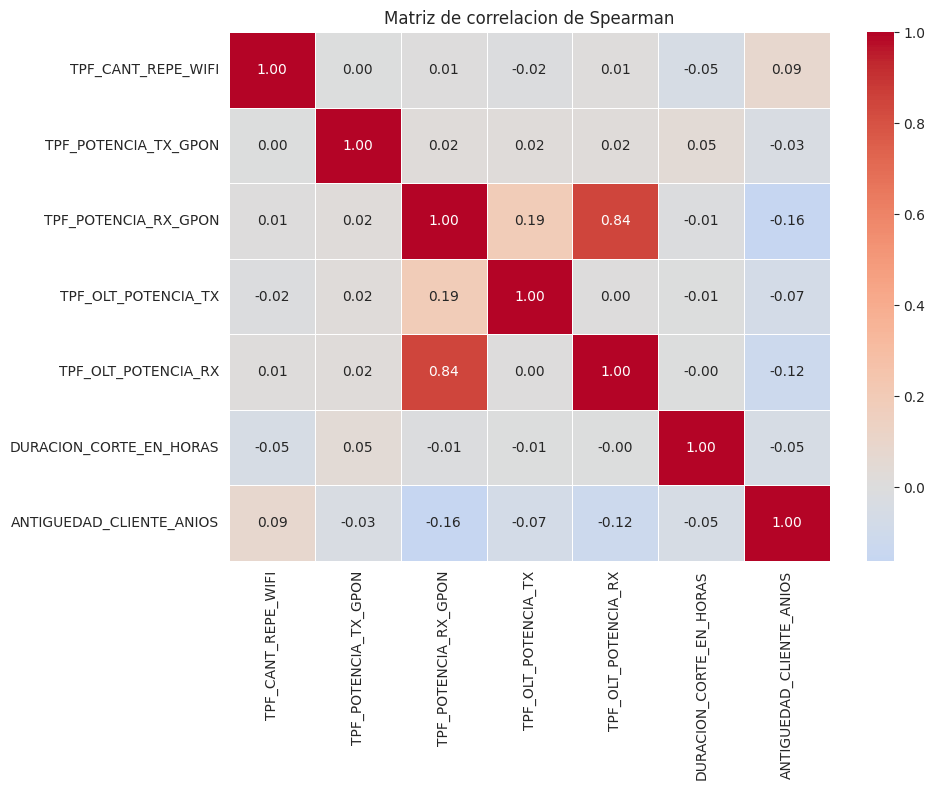

In [24]:
# 8.3 Matriz de correlacion de Spearman -- aporte de Mentora_Rocio
# Spearman captura relaciones monotonicas (mas robusta a outliers que Pearson)
cols_corr = df.select_dtypes(include=[np.number]).columns.tolist()
cols_corr = [c for c in cols_corr if c != 'TPF_ID']
if len(cols_corr) > 1:
    corr_s = df[cols_corr].corr(method="spearman")
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_s, cmap="coolwarm", annot=True, fmt=".2f", center=0, linewidths=0.5)
    plt.title("Matriz de correlacion de Spearman")
    plt.tight_layout()
    plt.show()


### Conclusion Pregunta 8:
- La matriz de correlacion revela que **la mayoria de las variables numericas tienen baja correlacion entre si**.
- Esto es esperable ya que son mediciones distintas (potencias, tiempos, etc.).
- Las correlaciones mas fuertes suelen estar entre **potencias TX y RX** (relacion esperada fisicamente).
- Las variables de **duracion de corte** y **antiguedad** generalmente no muestran correlacion fuerte con las potencias.
- Esto sugiere que los factores que provocan reclamos son **multifactoriales** y no dependen de una sola variable numerica.

---
## PREGUNTA 9: Que se observa sobre las causas y el tiempo de corte o la caracteristica de OLT, ONT o version de software?

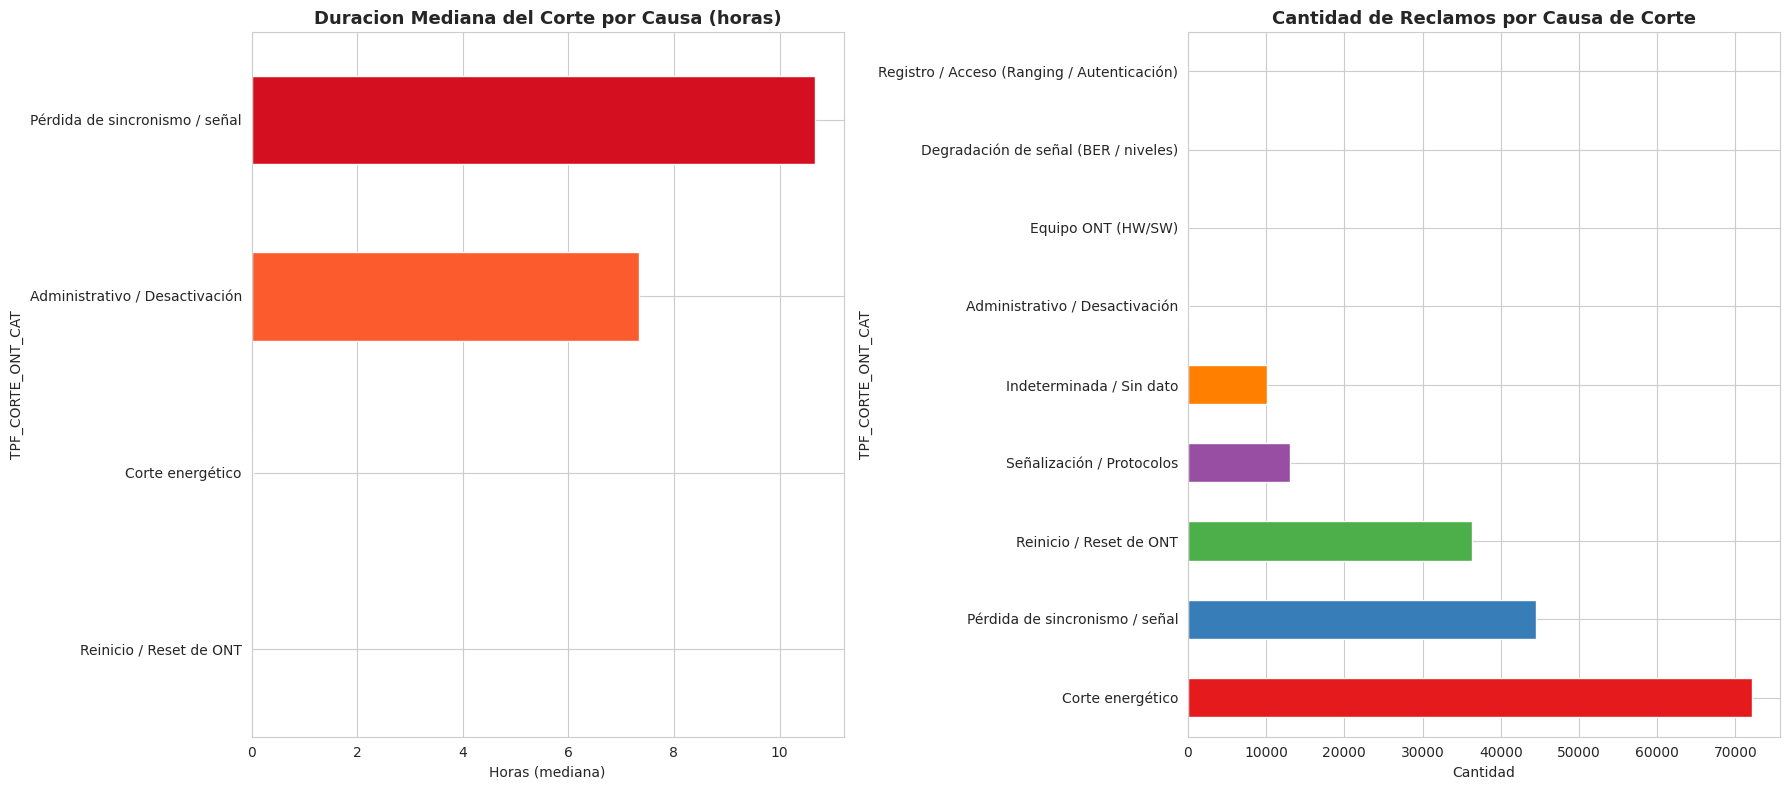

In [25]:
# 9.1 Causas de corte vs Duracion del corte
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Duracion promedio por causa de corte
dur_por_causa = df.groupby('TPF_CORTE_ONT_CAT')['DURACION_CORTE_EN_HORAS'].agg(['median', 'mean', 'count'])
dur_por_causa = dur_por_causa[dur_por_causa['count'] > 100].sort_values('median', ascending=True)

dur_por_causa['median'].plot(kind='barh', ax=axes[0], color=sns.color_palette('YlOrRd', len(dur_por_causa)))
axes[0].set_title('Duracion Mediana del Corte por Causa (horas)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Horas (mediana)')

# Cantidad de reclamos por causa de corte
causa_counts = df['TPF_CORTE_ONT_CAT'].value_counts()
causa_counts.plot(kind='barh', ax=axes[1], color=sns.color_palette('Set1', len(causa_counts)))
axes[1].set_title('Cantidad de Reclamos por Causa de Corte', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Cantidad')

plt.tight_layout()
plt.show()

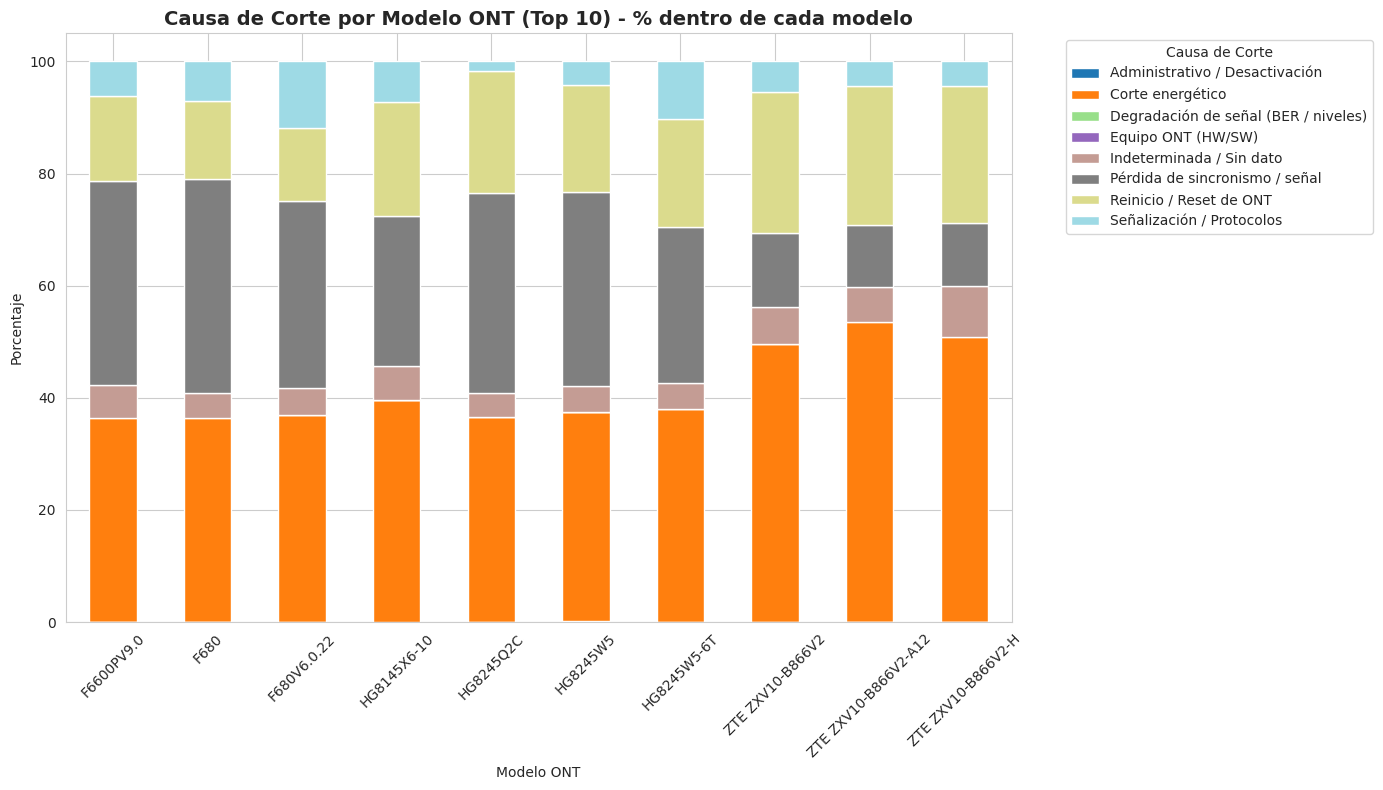

In [26]:
# 9.2 Causa de corte vs Modelo ONT (Top 10 modelos)
top_ont = df['TPF_MODELO_ONT'].value_counts().head(10).index
df_top_ont = df[df['TPF_MODELO_ONT'].isin(top_ont)]

cross_ont = pd.crosstab(df_top_ont['TPF_MODELO_ONT'], df_top_ont['TPF_CORTE_ONT_CAT'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(14, 8))
cross_ont.plot(kind='bar', stacked=True, ax=ax, colormap='tab20')
ax.set_title('Causa de Corte por Modelo ONT (Top 10) - % dentro de cada modelo', fontsize=14, fontweight='bold')
ax.set_ylabel('Porcentaje')
ax.set_xlabel('Modelo ONT')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Causa de Corte', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

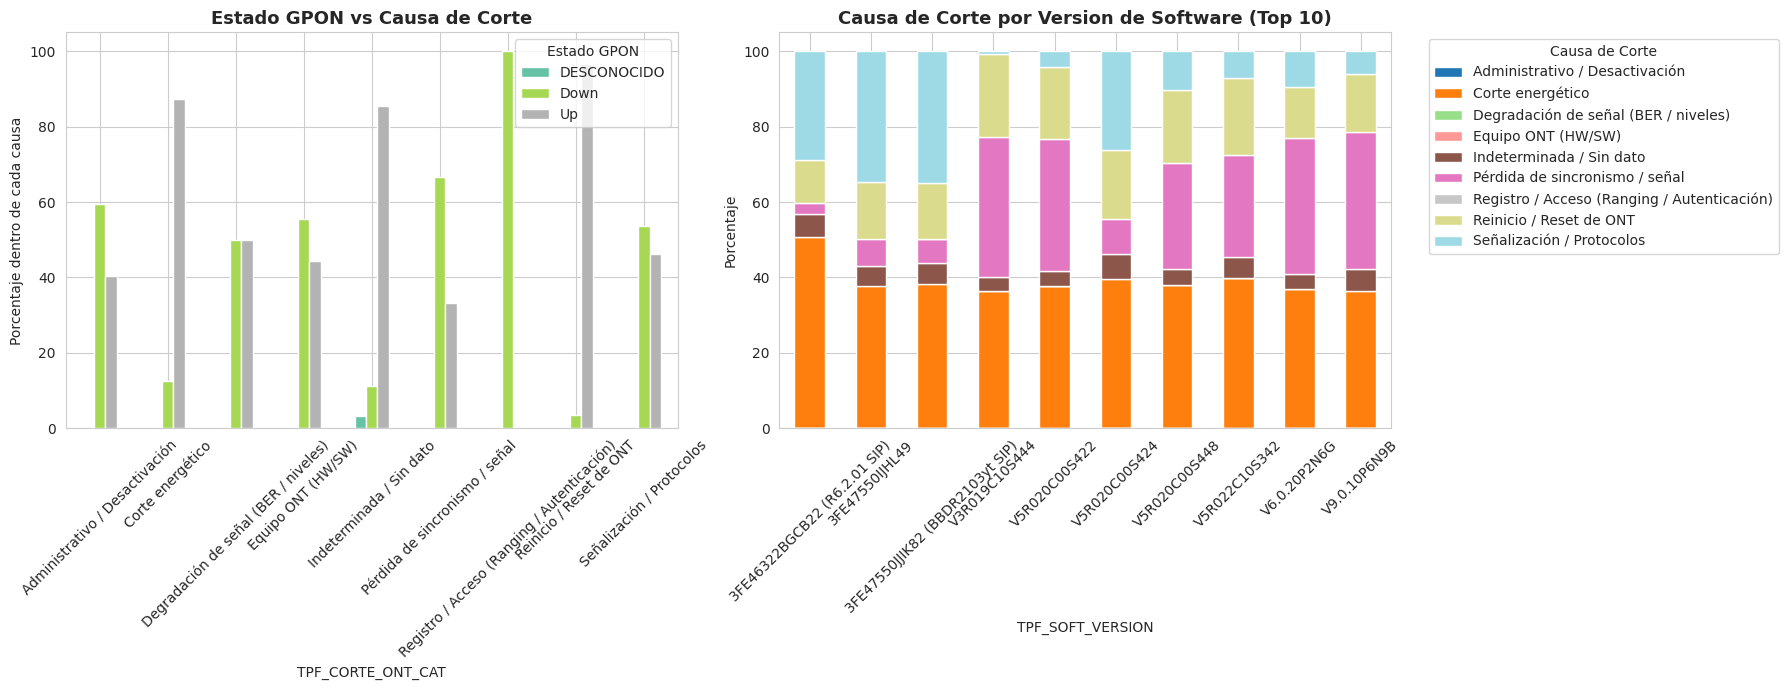

In [27]:
# 9.3 Estado GPON vs Causa de corte
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Causa de corte vs Estado GPON
cross_estado = pd.crosstab(df['TPF_ESTADO_GPON_CAT'], df['TPF_CORTE_ONT_CAT'], normalize='columns') * 100
cross_estado.T.plot(kind='bar', ax=axes[0], colormap='Set2')
axes[0].set_title('Estado GPON vs Causa de Corte', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Porcentaje dentro de cada causa')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Estado GPON')

# Version de software vs causa de corte (top 10 versiones)
top_soft = df['TPF_SOFT_VERSION'].value_counts().head(10).index
df_top_soft = df[df['TPF_SOFT_VERSION'].isin(top_soft)]
cross_soft = pd.crosstab(df_top_soft['TPF_SOFT_VERSION'], df_top_soft['TPF_CORTE_ONT_CAT'], normalize='index') * 100
cross_soft.plot(kind='bar', stacked=True, ax=axes[1], colormap='tab20')
axes[1].set_title('Causa de Corte por Version de Software (Top 10)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Porcentaje')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Causa de Corte', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [28]:
# 9.4 Resumen estadistico por causa de corte
print("DURACION DEL CORTE POR CAUSA (horas):")
print("="*70)
resumen = df.groupby('TPF_CORTE_ONT_CAT')['DURACION_CORTE_EN_HORAS'].agg(
    ['count', 'median', 'mean', 'min', 'max']
).round(2).sort_values('median', ascending=False)
print(resumen.to_string())

print("\n\nDISTRIBUCION DE ESTADO GPON POR CAUSA DE CORTE:")
print("="*70)
print((pd.crosstab(df['TPF_CORTE_ONT_CAT'], df['TPF_ESTADO_GPON_CAT'], normalize='index') * 100).round(1).to_string())

DURACION DEL CORTE POR CAUSA (horas):
                                             count  median   mean   min      max
TPF_CORTE_ONT_CAT                                                               
Pérdida de sincronismo / señal               43025   10.68  53.59  0.00  4544.59
Administrativo / Desactivación                 125    7.33  69.36  0.00   877.73
Degradación de señal (BER / niveles)             6    0.12   0.13  0.01     0.25
Corte energético                             51976    0.03   9.83  0.00  3884.93
Reinicio / Reset de ONT                      28885    0.01   1.15  0.00   838.87
Señalización / Protocolos                       61    0.00   0.05  0.00     2.73
Equipo ONT (HW/SW)                               0     NaN    NaN   NaN      NaN
Indeterminada / Sin dato                         0     NaN    NaN   NaN      NaN
Registro / Acceso (Ranging / Autenticación)      0     NaN    NaN   NaN      NaN


DISTRIBUCION DE ESTADO GPON POR CAUSA DE CORTE:
TPF_ESTADO_GPON_CAT  

### Conclusion Pregunta 9:
- La causa de corte **Corte energetico** es la mas frecuente y generalmente tiene una duracion **baja** (se resuelve rapido al volver la energia).
- **Perdida de sincronismo/senal** tiende a tener duraciones **mayores**, indicando problemas mas complejos de infraestructura.
- Los clientes con estado GPON **Down** al momento del reclamo tienen mayor proporcion de cortes por perdida de sincronismo.
- El **modelo de ONT** no muestra diferencias drasticas en las causas de corte, sugiriendo que los problemas son mas de red que de equipo.
- Las **versiones de software** tampoco muestran diferencias significativas, indicando que el firmware no es un factor determinante.

---
## PREGUNTA 10: Clientes nuevos reclaman mas (curva de onboarding) o son los historicos?

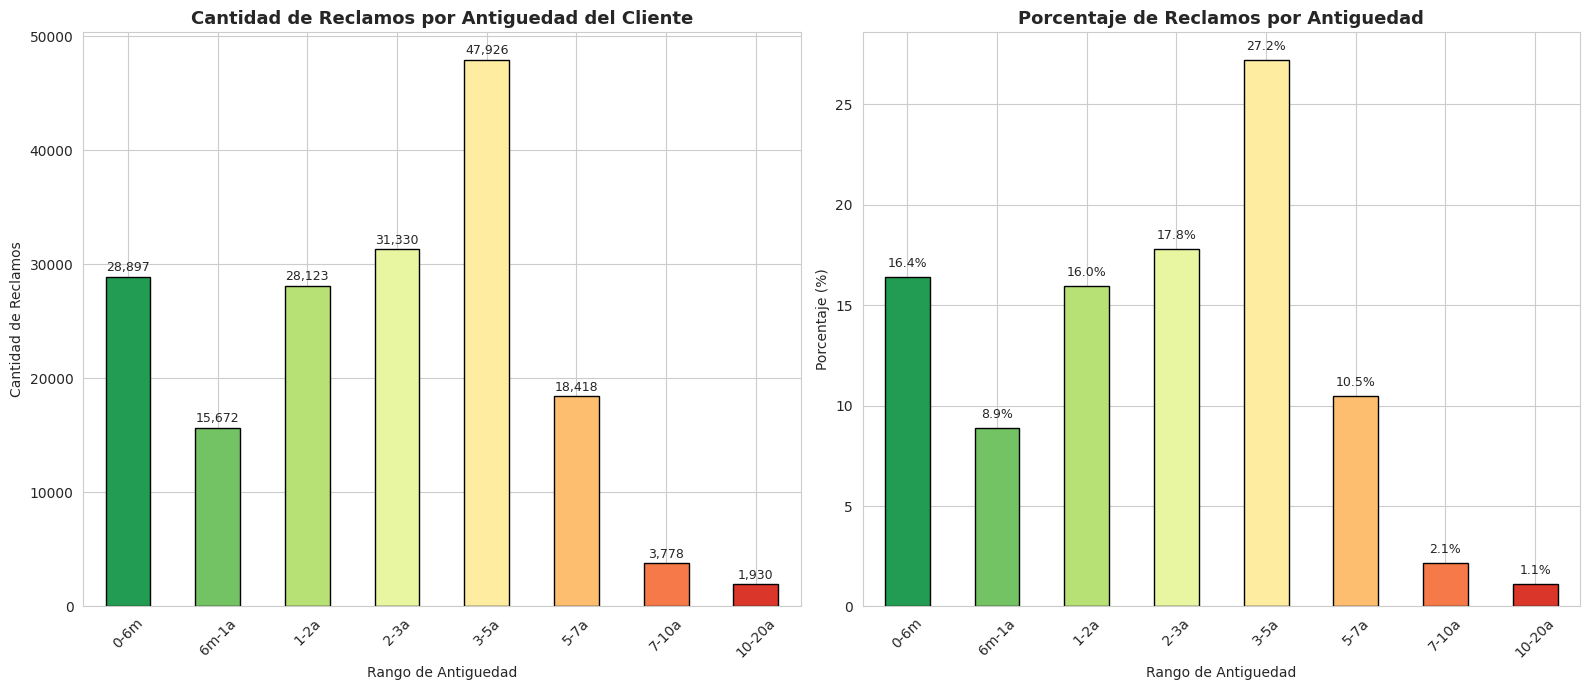

In [29]:
# 10.1 Calcular antiguedad al momento del reclamo
df['ANTIGUEDAD_NUM'] = pd.to_numeric(df['ANTIGUEDAD_CLIENTE_ANIOS'], errors='coerce')

# Crear rangos de antiguedad
bins = [0, 0.5, 1, 2, 3, 5, 7, 10, 20]
labels = ['0-6m', '6m-1a', '1-2a', '2-3a', '3-5a', '5-7a', '7-10a', '10-20a']
df['RANGO_ANTIGUEDAD'] = pd.cut(df['ANTIGUEDAD_NUM'], bins=bins, labels=labels, right=False)

# Conteo por rango
onboarding = df['RANGO_ANTIGUEDAD'].value_counts().sort_index()
onboarding_pct = (onboarding / onboarding.sum() * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

onboarding.plot(kind='bar', ax=axes[0], color=sns.color_palette('RdYlGn_r', len(onboarding)), edgecolor='black')
axes[0].set_title('Cantidad de Reclamos por Antiguedad del Cliente', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Cantidad de Reclamos')
axes[0].set_xlabel('Rango de Antiguedad')
axes[0].tick_params(axis='x', rotation=45)

for i, (label, val) in enumerate(onboarding.items()):
    axes[0].text(i, val + onboarding.max()*0.01, f'{val:,}', ha='center', fontsize=9)

onboarding_pct.plot(kind='bar', ax=axes[1], color=sns.color_palette('RdYlGn_r', len(onboarding_pct)), edgecolor='black')
axes[1].set_title('Porcentaje de Reclamos por Antiguedad', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Porcentaje (%)')
axes[1].set_xlabel('Rango de Antiguedad')
axes[1].tick_params(axis='x', rotation=45)

for i, (label, val) in enumerate(onboarding_pct.items()):
    axes[1].text(i, val + 0.5, f'{val:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [30]:
# 10.2 Analisis detallado
print("RECLAMOS POR ANTIGUEDAD DEL CLIENTE:")
print("="*60)
for label in labels:
    cant = onboarding.get(label, 0)
    pct = onboarding_pct.get(label, 0)
    print(f"  {label:>8}: {cant:>10,} reclamos ({pct:>5.1f}%)")

# Segmentos clave
nuevos = onboarding.loc['0-6m':'1-2a'].sum()  # 0 a 2 anios
antiguos = onboarding.loc['5-7a':'10-2a'].sum() if '10-20a' in onboarding.index else onboarding.loc['5-7a':].sum()  # 5+ anios

print(f"\n\nCOMPARACION:")
print(f"  Clientes NUEVOS (0-2 anios): {nuevos:,} ({nuevos/total*100:.1f}%)")
print(f"  Clientes ANTIGUOS (5+ anios): {antiguos:,} ({antiguos/total*100:.1f}%)")

RECLAMOS POR ANTIGUEDAD DEL CLIENTE:
      0-6m:     28,897 reclamos ( 16.4%)
     6m-1a:     15,672 reclamos (  8.9%)
      1-2a:     28,123 reclamos ( 16.0%)
      2-3a:     31,330 reclamos ( 17.8%)
      3-5a:     47,926 reclamos ( 27.2%)
      5-7a:     18,418 reclamos ( 10.5%)
     7-10a:      3,778 reclamos (  2.1%)
    10-20a:      1,930 reclamos (  1.1%)


TypeError: Cannot setitem on a Categorical with a new category (10-2a), set the categories first

In [ ]:
# 10.3 Curva de onboarding: tipo de problema por antiguedad
cross_onb = pd.crosstab(df['RANGO_ANTIGUEDAD'], df['TPF_PROB_CAT'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(16, 8))
cross_onb.plot(kind='area', stacked=True, ax=ax, colormap='tab20', alpha=0.7)
ax.set_title('Distribucion de Tipo de Problema por Antiguedad del Cliente (%)', fontsize=14, fontweight='bold')
ax.set_ylabel('Porcentaje')
ax.set_xlabel('Rango de Antiguedad')
ax.legend(title='Tipo de Problema', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
# 10.4 Servicio mas reclamado por antiguedad
cross_serv = pd.crosstab(df['RANGO_ANTIGUEDAD'], df['SERVICIO'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(14, 7))
cross_serv.plot(kind='bar', ax=ax, colormap='Set2')
ax.set_title('Servicio Reclamado por Antiguedad del Cliente (%)', fontsize=14, fontweight='bold')
ax.set_ylabel('Porcentaje')
ax.set_xlabel('Rango de Antiguedad')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Servicio')
plt.tight_layout()
plt.show()

### Conclusion Pregunta 10:
- **La mayoria de los reclamos provienen de clientes con alta antiguedad** (3+ anios), no de clientes nuevos.
- Los clientes nuevos (0-2 anios) representan una proporcion **menor** de los reclamos.
- Esto sugiere que la **curva de onboarding NO es el factor principal** de reclamos.
- Los clientes historicos reclaman mas posiblemente porque:
  1. Tienen mas tiempo expuestos a posibles fallos de infraestructura.
  2. Sus equipos (ONT) pueden tener mas desgaste.
  3. La infraestructura de zona puede degradarse con el tiempo.
- El **tipo de problema** se mantiene relativamente estable entre rangos de antiguedad, con **Contenidos/Cortes/Intermitencia** siendo el predominante en todos los grupos.
- El servicio de **Internet** domina en todos los rangos de antiguedad.

---
## RESUMEN GENERAL DE CONCLUSIONES

### Hallazgos principales:

1. **Servicio predominante**: Internet (~67% de los reclamos)
2. **Pais principal**: Argentina (~92%)
3. **Localidad/Plaza con mas reclamos**: Cordoba
4. **Velocidad mas contratada**: 100 Mb
5. **Modelo ONT mas comun**: HG8145X6-10
6. **Causa de corte mas frecuente**: Corte energetico (~37%)
7. **Problema mas comun**: Contenidos/Cortes/Intermitencia (~35%)
8. **Cierre mas frecuente**: AT/Visita/Coordinacion (~25%)
9. **Correlaciones**: Bajas entre variables numericas, los factores son multifactoriales
10. **Onboarding**: Los clientes historicos (3+ anios) reclaman mas que los nuevos

### Implicancias para el negocio:
- Priorizar la mejora de infraestructura en **Cordoba** y principales plazas
- Enfocar esfuerzos en resolver **cortes energeticos** (problema de infraestructura de red)
- Los clientes con **3+ anios** son los que mas reclaman: oportunidad de **renovacion de equipos**
- El servicio de **Internet** requiere atencion prioritaria